# Proyecto Final Data Mining - CASEN 2024

Clasificación supervisada de pobreza por ingresos en hogares chilenos.

## 1. Configuración y carga de datos

In [1]:
# ============================================================
# BLOQUE 1: Configuración inicial y carga de datos
# ============================================================

import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

warnings.filterwarnings("ignore")

SEED = 123
np.random.seed(SEED)
random.seed(SEED)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.autolayout": True
})

PALETA = {
    "azul": "#2F6B9A",
    "celeste": "#74A9CF",
    "naranjo": "#F28E2B",
    "verde": "#59A14F",
    "rojo": "#E15759",
    "gris": "#4E5D6C"
}

# Conexión a Google Drive
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("Entorno local detectado. No se montó Google Drive.")

ruta_proyecto = "/content/drive/MyDrive/DataMining_CASEN2024"
ruta_datos_procesados = os.path.join(ruta_proyecto, "datos_procesados")

ruta_parquet = os.path.join(ruta_datos_procesados, "casen2024_modelamiento.parquet")
ruta_csv = os.path.join(ruta_datos_procesados, "casen2024_modelamiento.csv")

if os.path.exists(ruta_parquet):
    df = pd.read_parquet(ruta_parquet)
    print("Base cargada desde archivo Parquet.")
elif os.path.exists(ruta_csv):
    df = pd.read_csv(ruta_csv)
    print("Base cargada desde archivo CSV.")
else:
    raise FileNotFoundError("No se encontró la base limpia en datos_procesados.")

print("Dimensión de la base:", df.shape)
display(df.head())


Mounted at /content/drive
Base cargada desde archivo Parquet.
Dimensión de la base: (78654, 29)


,pobreza_ingresos,edad,jefatura_mujer,ecivil,esc,activ,contrato,cotiza,disc_wg,pueblos_indigenas,nacido_fuera_chile,numper,tipohogar,men18c,may60c,n_ocupados,n_desocupados,n_inactivos,tasa_ocupados_hogar,tasa_desocupados_hogar,tasa_inactivos_hogar,region,area,ind_hacina,ind_san,ind_mat,ind_estado,ind_cal_glob,ten_viv_f
0,0.000,62,0,8.000,12.000,3.000,2.000,0.000,1.000,0,0,2,2,0,1,0,0,2,0.000,0.000,1.000,13,1,1,1,1,2,1,1
1,0.000,61,0,1.000,8.000,1.000,1.000,1.000,0.000,0,0,4,3,0,1,4,0,0,1.000,0.000,0.000,13,1,1,1,1,1,1,1
2,0.000,55,0,1.000,14.000,1.000,1.000,1.000,1.000,0,0,1,1,0,0,1,0,0,1.000,0.000,0.000,13,1,1,1,3,3,2,2
3,0.000,54,1,1.000,12.000,3.000,2.000,0.000,0.000,0,0,5,3,1,0,2,0,2,0.400,0.000,0.400,13,1,1,1,1,2,1,1
4,0.000,35,0,1.000,13.000,1.000,1.000,1.000,0.000,1,0,5,3,1,0,2,0,1,0.400,0.000,0.200,2,1,1,1,1,1,1,1


In [2]:
# ============================================================
# BLOQUE 2: Funciones auxiliares
# ============================================================

def mostrar_titulo(texto, ancho=80):
    print("\n" + texto)
    print("=" * ancho)


def tabla_pobreza_categoria(data, variable, ordenar=True):
    tabla = pd.crosstab(data[variable], data["pobreza_ingresos"])
    tabla = tabla.reindex(columns=[0, 1], fill_value=0)
    tabla.columns = ["No pobreza", "Pobreza"]
    tabla["Total"] = tabla["No pobreza"] + tabla["Pobreza"]
    tabla["Porcentaje pobreza"] = (tabla["Pobreza"] / tabla["Total"] * 100).round(2)
    tabla["Porcentaje del total"] = (tabla["Total"] / len(data) * 100).round(2)

    if ordenar:
        tabla = tabla.sort_values("Porcentaje pobreza", ascending=False)

    return tabla


def graficar_barras_porcentaje(tabla, titulo, xlabel="Categoría", top=None):
    datos = tabla.copy()
    if top is not None:
        datos = datos.head(top)

    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(datos))))
    valores = datos["Porcentaje pobreza"]
    y_pos = np.arange(len(datos))

    ax.barh(y_pos, valores, color=PALETA["azul"])
    ax.set_yticks(y_pos)
    ax.set_yticklabels(datos.index.astype(str))
    ax.invert_yaxis()
    ax.set_title(titulo)
    ax.set_xlabel("Porcentaje de hogares en pobreza")
    ax.set_ylabel(xlabel)

    for i, v in enumerate(valores):
        ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)

    ax.set_xlim(0, max(valores.max() + 8, 10))
    plt.show()


def cramer_v(tabla_contingencia):
    chi2, p_valor, gl, _ = chi2_contingency(tabla_contingencia)
    n = tabla_contingencia.sum().sum()
    filas, columnas = tabla_contingencia.shape
    v = np.sqrt(chi2 / (n * min(filas - 1, columnas - 1)))
    return v, chi2, p_valor, gl


def evaluar_modelo(nombre_modelo, y_real, y_pred, y_prob):
    return {
        "modelo": nombre_modelo,
        "accuracy": accuracy_score(y_real, y_pred),
        "precision": precision_score(y_real, y_pred, zero_division=0),
        "recall": recall_score(y_real, y_pred, zero_division=0),
        "f1_score": f1_score(y_real, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_real, y_prob),
        "pr_auc": average_precision_score(y_real, y_prob)
    }


def mostrar_matriz_confusion(nombre_modelo, y_real, y_pred):
    matriz = confusion_matrix(y_real, y_pred)
    tabla = pd.DataFrame(
        matriz,
        index=["Real: No pobreza", "Real: Pobreza"],
        columns=["Predicho: No pobreza", "Predicho: Pobreza"]
    )

    mostrar_titulo(f"Matriz de confusión - {nombre_modelo}")
    display(tabla)

    fig, ax = plt.subplots(figsize=(5.8, 4.8))
    im = ax.imshow(matriz, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No pobreza", "Pobreza"])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["No pobreza", "Pobreza"])
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
    ax.set_title(nombre_modelo)

    for i in range(matriz.shape[0]):
        for j in range(matriz.shape[1]):
            ax.text(j, i, f"{matriz[i, j]:,}".replace(",", "."),
                    ha="center", va="center", fontsize=11)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.show()

    return tabla


In [3]:
# ============================================================
# BLOQUE 3: Diccionarios y variables de trabajo
# ============================================================

map_area = {1: "Urbana", 2: "Rural"}
map_region = {
    1: "Tarapacá", 2: "Antofagasta", 3: "Atacama", 4: "Coquimbo",
    5: "Valparaíso", 6: "O'Higgins", 7: "Maule", 8: "Biobío",
    9: "La Araucanía", 10: "Los Lagos", 11: "Aysén", 12: "Magallanes",
    13: "Metropolitana", 14: "Los Ríos", 15: "Arica y Parinacota", 16: "Ñuble"
}
map_activ = {1: "Ocupado", 2: "Desocupado", 3: "Inactivo"}
map_contrato = {0: "No", 1: "Sí", 2: "No aplica", 3: "No sabe"}
map_cotiza = {0: "No", 1: "Sí", 2: "No sabe"}
map_jefatura = {0: "Jefatura hombre", 1: "Jefatura mujer"}
map_pueblos = {0: "No pertenece", 1: "Pertenece"}
map_disc = {0: "Sin discapacidad", 1: "Con discapacidad", 2: "No sabe"}
map_nacimiento = {0: "Nacido en Chile", 1: "Nacido fuera de Chile", 2: "No sabe"}
map_menores = {0: "Sin menores", 1: "Con menores"}
map_mayores = {0: "Sin adultos mayores", 1: "Con adultos mayores"}
map_hacina = {1: "Sin hacinamiento", 2: "Medio", 3: "Alto", 4: "Crítico", 5: "No sabe"}
map_san = {1: "Aceptable", 2: "Deficitario"}
map_mat = {1: "Aceptable", 2: "Recup. muro", 3: "Recup. resto", 4: "Irrecuperable"}
map_estado = {1: "Bueno", 2: "Regular", 3: "Malo"}
map_calidad = {1: "Aceptable", 2: "Recuperable", 3: "Irrecuperable"}
map_tenencia = {1: "Formal", 2: "Informal"}

variables_numericas_eda = [
    "edad", "esc", "numper",
    "tasa_ocupados_hogar", "tasa_desocupados_hogar", "tasa_inactivos_hogar"
]

variables_numericas_modelo = [
    "pobreza_ingresos", "edad", "esc", "numper", "n_ocupados", "n_desocupados", "n_inactivos",
    "tasa_ocupados_hogar", "tasa_desocupados_hogar", "tasa_inactivos_hogar"
]

variables_categoricas = [
    "jefatura_mujer", "ecivil", "activ", "contrato", "cotiza", "disc_wg",
    "pueblos_indigenas", "nacido_fuera_chile", "tipohogar", "men18c", "may60c",
    "region", "area", "ind_hacina", "ind_san", "ind_mat", "ind_estado",
    "ind_cal_glob", "ten_viv_f"
]

variables_numericas_logistica = [
    "edad", "esc", "numper",
    "tasa_ocupados_hogar", "tasa_desocupados_hogar", "tasa_inactivos_hogar"
]

variables_categoricas_logistica = variables_categoricas.copy()
variables_predictoras_logistica = variables_numericas_logistica + variables_categoricas_logistica


## 2. Revisión inicial y EDA


Resumen general de la base
Número de hogares: 78654
Número de variables: 29
Valores perdidos: 0


,cantidad
int8,17
float64,9
int64,2
int16,1



Distribución de pobreza_ingresos


,frecuencia,porcentaje
No pobreza,63059,80.170
Pobreza,15595,19.830


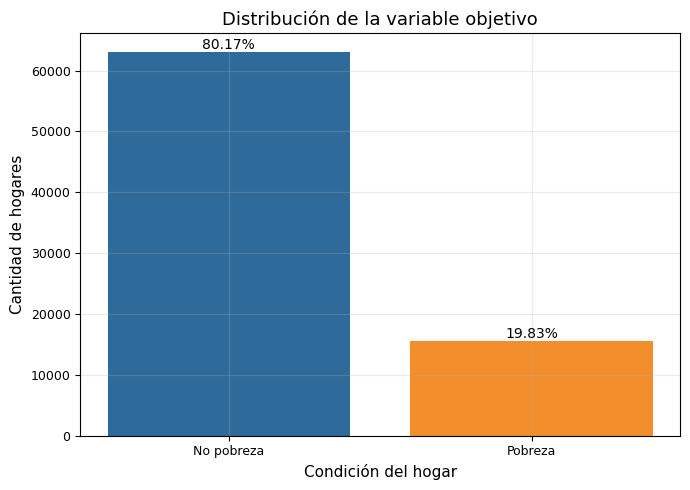

In [4]:
# ============================================================
# BLOQUE 4: Revisión general de la base y variable objetivo
# ============================================================

df_eda = df.copy()
df_eda["pobreza_ingresos"] = df_eda["pobreza_ingresos"].astype(int)

mostrar_titulo("Resumen general de la base")
print("Número de hogares:", df_eda.shape[0])
print("Número de variables:", df_eda.shape[1])
print("Valores perdidos:", df_eda.isna().sum().sum())
display(df_eda.dtypes.value_counts().to_frame("cantidad"))

tabla_objetivo = pd.DataFrame({
    "frecuencia": df_eda["pobreza_ingresos"].value_counts().sort_index(),
    "porcentaje": df_eda["pobreza_ingresos"].value_counts(normalize=True).sort_index() * 100
})
tabla_objetivo.index = ["No pobreza", "Pobreza"]
tabla_objetivo["porcentaje"] = tabla_objetivo["porcentaje"].round(2)

mostrar_titulo("Distribución de pobreza_ingresos")
display(tabla_objetivo)

fig, ax = plt.subplots(figsize=(7, 5))
barras = ax.bar(tabla_objetivo.index, tabla_objetivo["frecuencia"], color=[PALETA["azul"], PALETA["naranjo"]])
ax.set_title("Distribución de la variable objetivo")
ax.set_xlabel("Condición del hogar")
ax.set_ylabel("Cantidad de hogares")

for barra, porcentaje in zip(barras, tabla_objetivo["porcentaje"]):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height(), f"{porcentaje:.2f}%",
            ha="center", va="bottom", fontsize=10)

plt.show()



Resumen descriptivo de variables numéricas


,count,mean,std,min,25%,50%,75%,max
edad,"78,654.000",54.698,16.268,16.000,42.000,55.000,67.000,103.000
esc,"78,654.000",11.274,4.417,0.000,8.000,12.000,15.000,31.000
numper,"78,654.000",2.775,1.461,1.000,2.000,3.000,4.000,19.000
tasa_ocupados_hogar,"78,654.000",0.461,0.347,0.000,0.200,0.500,0.667,1.000
tasa_desocupados_hogar,"78,654.000",0.043,0.142,0.000,0.000,0.000,0.000,1.000
tasa_inactivos_hogar,"78,654.000",0.379,0.365,0.000,0.000,0.333,0.667,1.000



Medias de variables numéricas según pobreza


,No pobreza,Pobreza,Diferencia pobreza - no pobreza
edad,55.023,53.380,-1.643
esc,11.645,9.774,-1.871
numper,2.782,2.746,-0.036
tasa_ocupados_hogar,0.517,0.233,-0.284
tasa_desocupados_hogar,0.033,0.084,0.051
tasa_inactivos_hogar,0.345,0.517,0.172


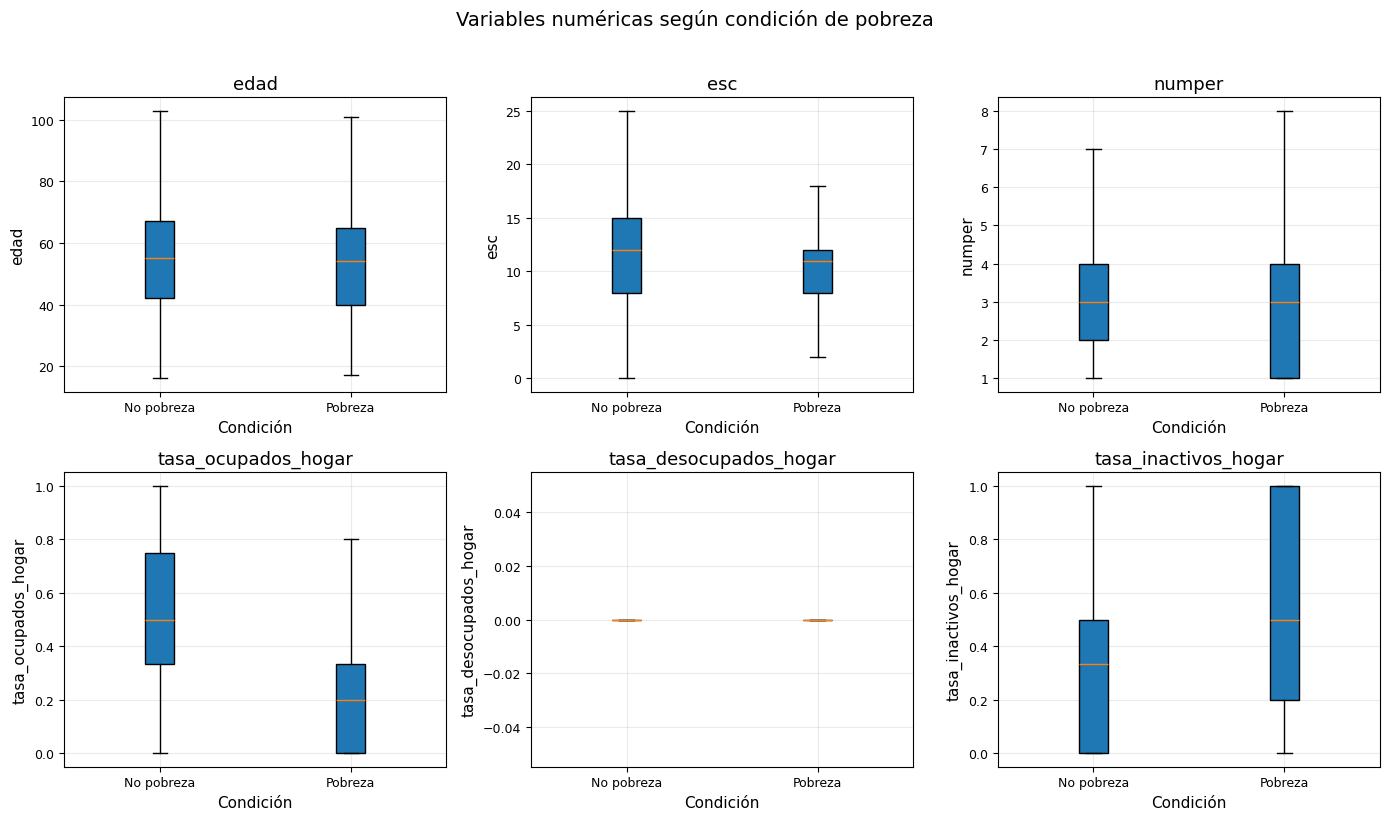

In [5]:
# ============================================================
# BLOQUE 5: EDA bivariado de variables numéricas
# ============================================================

mostrar_titulo("Resumen descriptivo de variables numéricas")
display(df_eda[variables_numericas_eda].describe().T.round(3))

mostrar_titulo("Medias de variables numéricas según pobreza")
tabla_medias = df_eda.groupby("pobreza_ingresos")[variables_numericas_eda].mean().T
tabla_medias.columns = ["No pobreza", "Pobreza"]
tabla_medias["Diferencia pobreza - no pobreza"] = tabla_medias["Pobreza"] - tabla_medias["No pobreza"]
display(tabla_medias.round(3))

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, var in zip(axes, variables_numericas_eda):
    datos_plot = [
        df_eda.loc[df_eda["pobreza_ingresos"] == 0, var],
        df_eda.loc[df_eda["pobreza_ingresos"] == 1, var]
    ]
    ax.boxplot(datos_plot, tick_labels=["No pobreza", "Pobreza"], showfliers=False, patch_artist=True)
    ax.set_title(var)
    ax.set_xlabel("Condición")
    ax.set_ylabel(var)

fig.suptitle("Variables numéricas según condición de pobreza", fontsize=14, y=1.02)
plt.show()



EDA categórico: Laborales

Variable: activ_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
activ_label,,,,,
Desocupado,1445,1319,2764,47.720,3.510
Inactivo,19593,7810,27403,28.500,34.840
Ocupado,42021,6466,48487,13.340,61.650


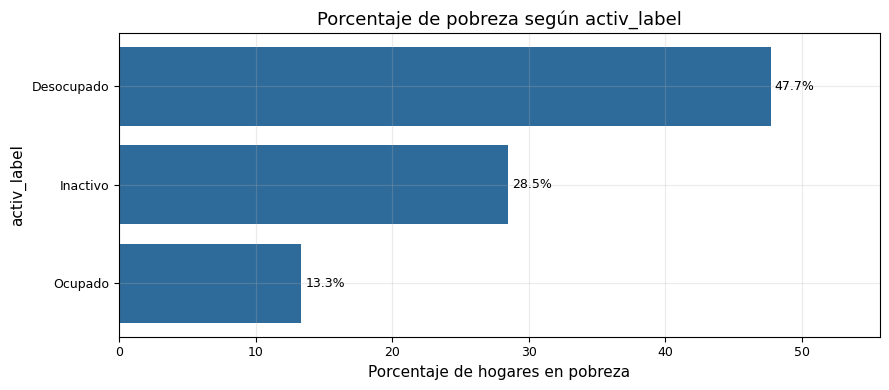


Variable: contrato_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
contrato_label,,,,,
No aplica,31583,12103,43686,27.700,55.540
No,3318,1153,4471,25.790,5.680
No sabe,52,7,59,11.860,0.080
Sí,28106,2332,30438,7.660,38.700


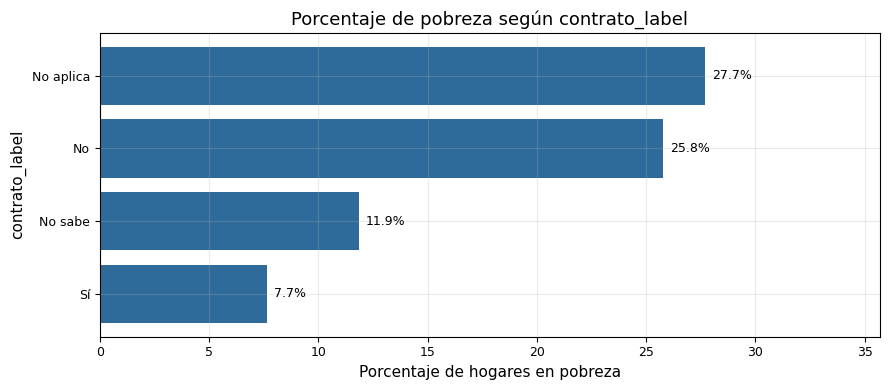


Variable: cotiza_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
cotiza_label,,,,,
No,29713,12066,41779,28.880,53.120
No sabe,155,57,212,26.890,0.270
Sí,33191,3472,36663,9.470,46.610


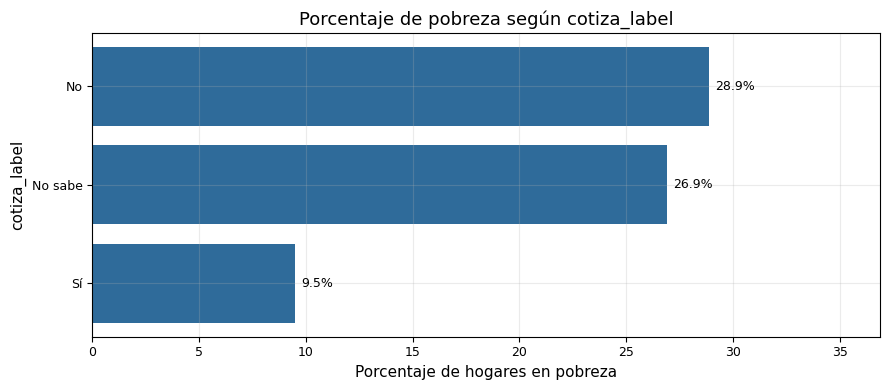


EDA categórico: Educación y hogar

Variable: grupo_escolaridad


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
grupo_escolaridad,,,,,
0 a 8 años,16145,5890,22035,26.730,28.020
9 a 12 años,23715,7098,30813,23.040,39.180
13 a 16 años,12876,2020,14896,13.560,18.940
17 años o más,10323,587,10910,5.380,13.870


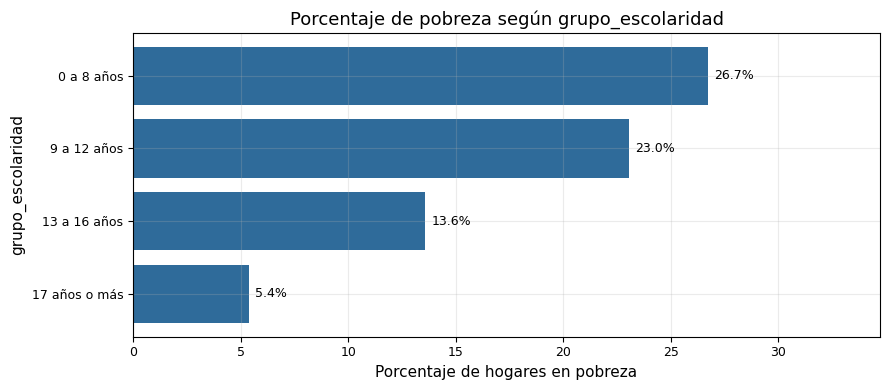


Variable: grupo_tamano_hogar


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
grupo_tamano_hogar,,,,,
1 persona,11771,4171,15942,26.160,20.270
4 a 5 personas,14780,3951,18731,21.090,23.810
6 o más personas,2700,709,3409,20.800,4.330
2 a 3 personas,33808,6764,40572,16.670,51.580


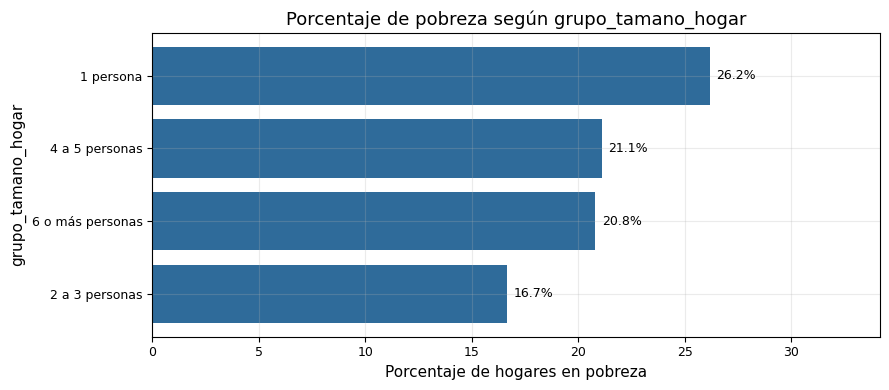


Variable: tipohogar_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
tipohogar_label,,,,,
Tipo 2,11492,4450,15942,27.910,20.270
Tipo 1,11771,4171,15942,26.160,20.270
Tipo 4,4091,902,4993,18.070,6.350
Tipo 3,29523,5253,34776,15.110,44.210
Tipo 6,1472,233,1705,13.670,2.170
Tipo 5,4710,586,5296,11.060,6.730


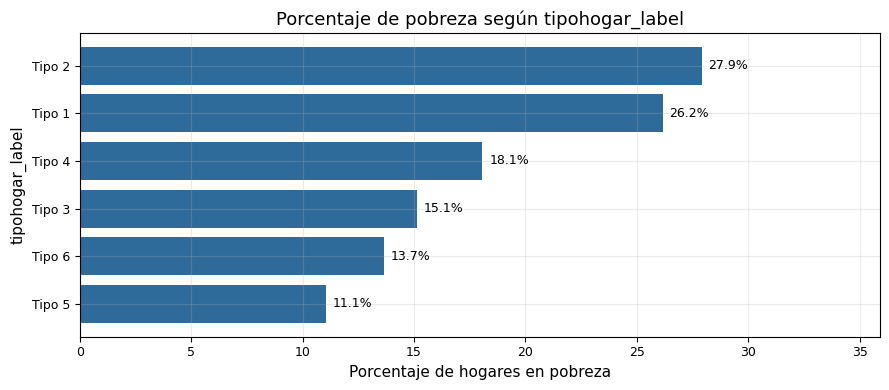


Variable: menores_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
menores_label,,,,,
Con menores,21802,7177,28979,24.770,36.840
Sin menores,41257,8418,49675,16.950,63.160


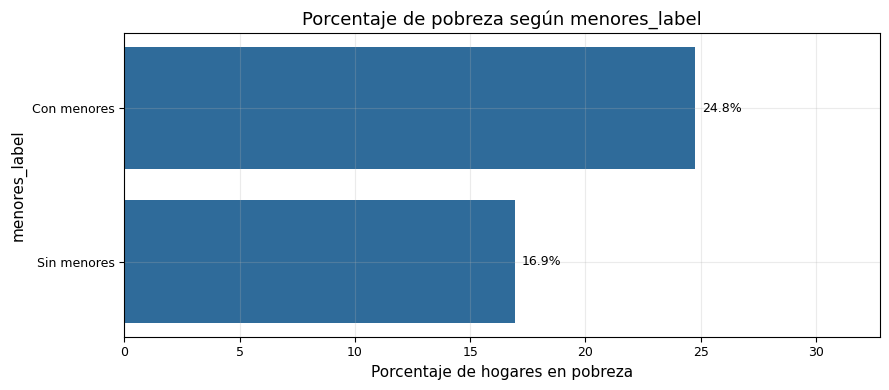


Variable: mayores_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
mayores_label,,,,,
Sin adultos mayores,33106,8940,42046,21.260,53.460
Con adultos mayores,29953,6655,36608,18.180,46.540


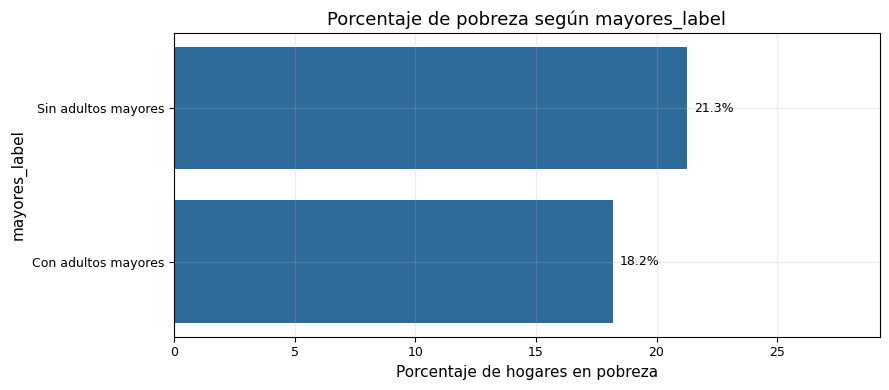


EDA categórico: Territorio y vivienda

Variable: area_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
area_label,,,,,
Rural,10595,3627,14222,25.500,18.080
Urbana,52464,11968,64432,18.570,81.920


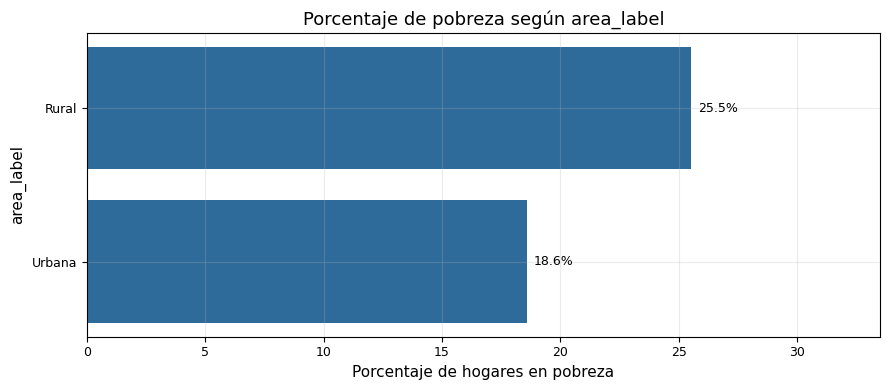


Variable: region_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
region_label,,,,,
La Araucanía,3783,1675,5458,30.690,6.940
Ñuble,2594,902,3496,25.800,4.440
Maule,4161,1417,5578,25.400,7.090
Los Ríos,2620,813,3433,23.680,4.360
Coquimbo,2818,820,3638,22.540,4.630
Arica y Parinacota,2225,570,2795,20.390,3.550
Biobío,6471,1653,8124,20.350,10.330
Atacama,2602,655,3257,20.110,4.140
Tarapacá,2484,609,3093,19.690,3.930


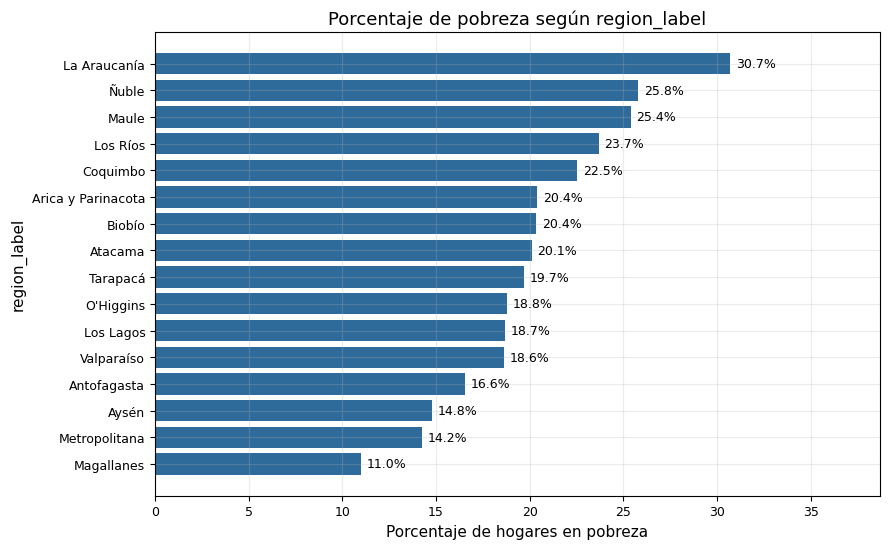


Variable: hacina_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
hacina_label,,,,,
Alto,166,172,338,50.890,0.430
Crítico,124,102,226,45.130,0.290
No sabe,12,9,21,42.860,0.030
Medio,1330,803,2133,37.650,2.710
Sin hacinamiento,61427,14509,75936,19.110,96.540


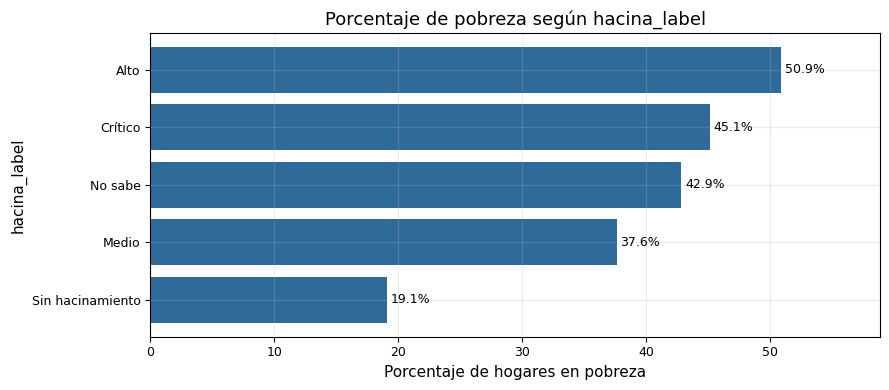


Variable: san_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
san_label,,,,,
Deficitario,3106,1671,4777,34.980,6.070
Aceptable,59953,13924,73877,18.850,93.930


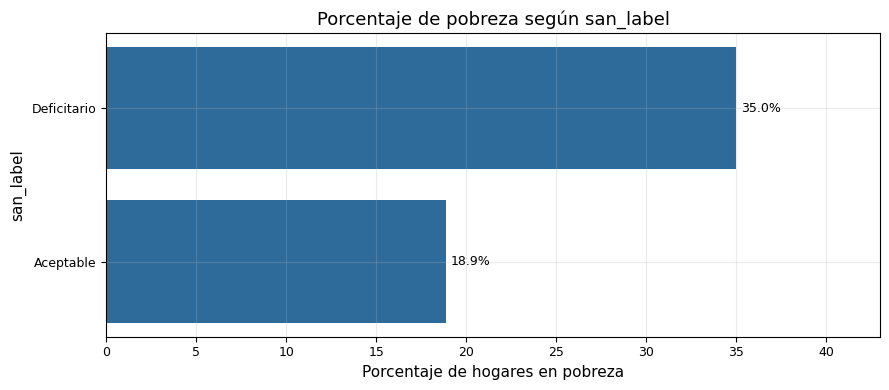


Variable: calidad_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
calidad_label,,,,,
Irrecuperable,166,134,300,44.670,0.380
Recuperable,5553,2715,8268,32.840,10.510
Aceptable,57340,12746,70086,18.190,89.110


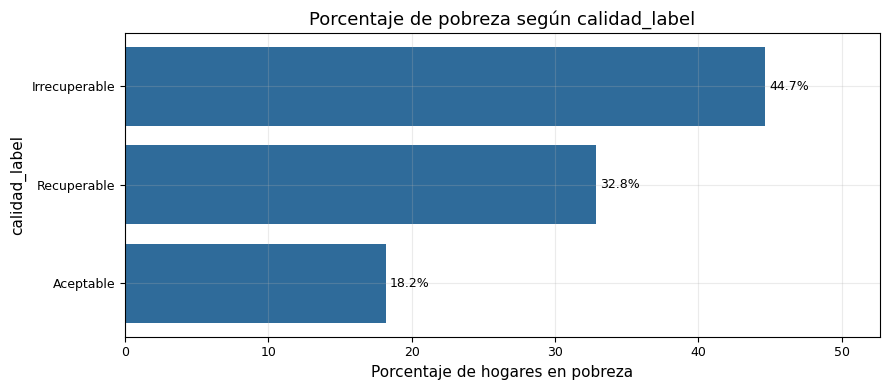


Variable: tenencia_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
tenencia_label,,,,,
Informal,11948,5028,16976,29.620,21.580
Formal,51111,10567,61678,17.130,78.420


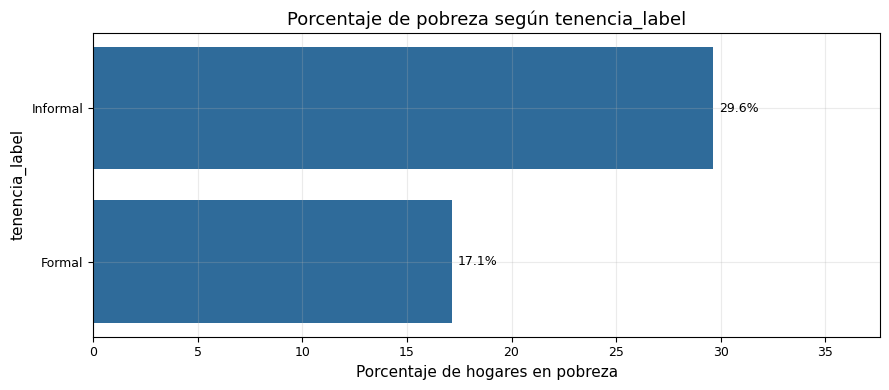


EDA categórico: Jefatura y vulnerabilidad

Variable: jefatura_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
jefatura_label,,,,,
Jefatura mujer,30917,9822,40739,24.110,51.800
Jefatura hombre,32142,5773,37915,15.230,48.200


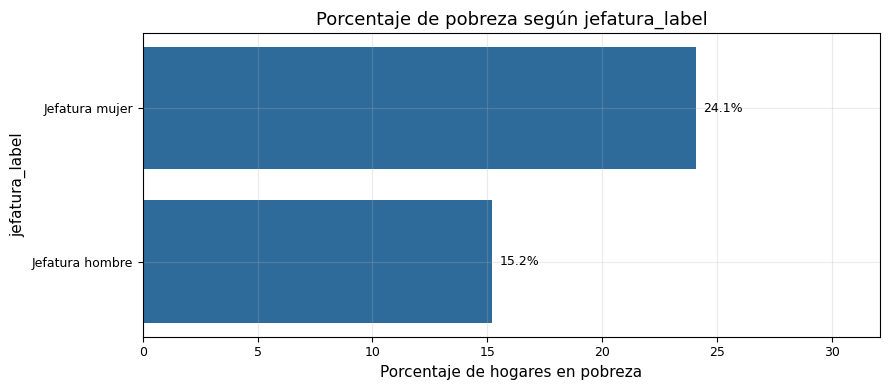


Variable: pueblos_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
pueblos_label,,,,,
Pertenece,7592,2557,10149,25.190,12.900
No pertenece,55467,13038,68505,19.030,87.100


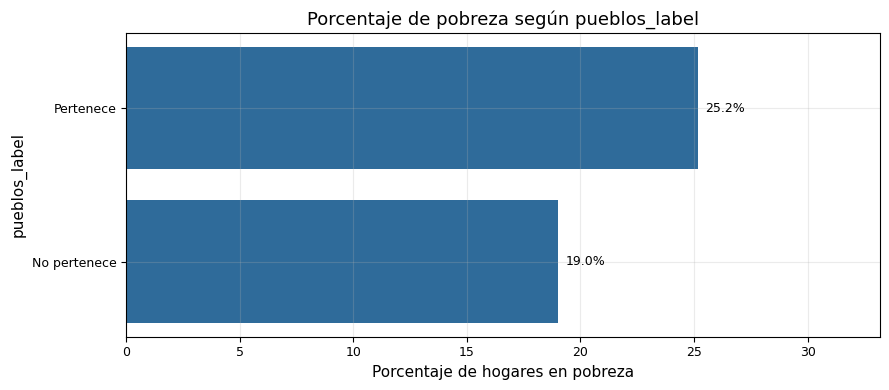


Variable: disc_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
disc_label,,,,,
No sabe,8,3,11,27.270,0.010
Con discapacidad,9087,3083,12170,25.330,15.470
Sin discapacidad,53964,12509,66473,18.820,84.510


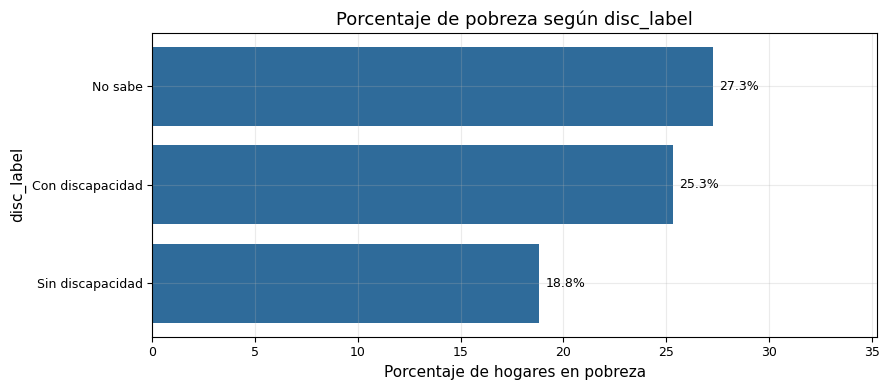


Variable: nacimiento_label


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
nacimiento_label,,,,,
Nacido fuera de Chile,3639,1386,5025,27.580,6.390
No sabe,296,84,380,22.110,0.480
Nacido en Chile,59124,14125,73249,19.280,93.130


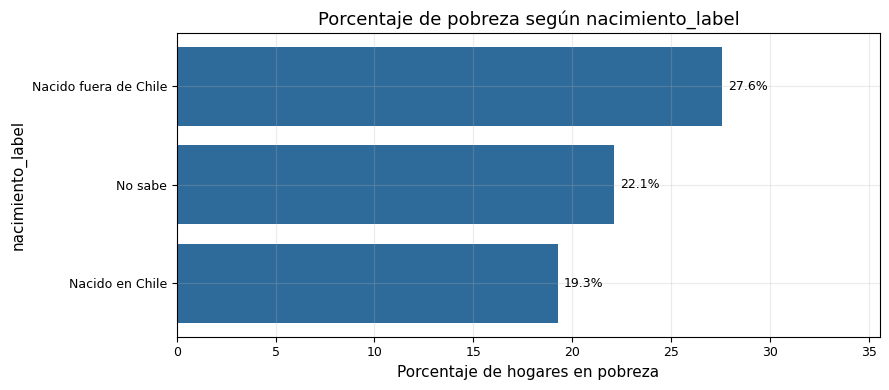

In [6]:
# ============================================================
# BLOQUE 6: EDA bivariado de variables categóricas seleccionadas
# ============================================================

# Variables etiquetadas para gráficos y tablas descriptivas
df_cat = df_eda.copy()
df_cat["activ_label"] = df_cat["activ"].map(map_activ)
df_cat["contrato_label"] = df_cat["contrato"].map(map_contrato)
df_cat["cotiza_label"] = df_cat["cotiza"].map(map_cotiza)
df_cat["jefatura_label"] = df_cat["jefatura_mujer"].map(map_jefatura)
df_cat["pueblos_label"] = df_cat["pueblos_indigenas"].map(map_pueblos)
df_cat["disc_label"] = df_cat["disc_wg"].map(map_disc)
df_cat["nacimiento_label"] = df_cat["nacido_fuera_chile"].map(map_nacimiento)
df_cat["menores_label"] = df_cat["men18c"].map(map_menores)
df_cat["mayores_label"] = df_cat["may60c"].map(map_mayores)
df_cat["area_label"] = df_cat["area"].map(map_area)
df_cat["region_label"] = df_cat["region"].map(map_region)
df_cat["hacina_label"] = df_cat["ind_hacina"].map(map_hacina)
df_cat["san_label"] = df_cat["ind_san"].map(map_san)
df_cat["calidad_label"] = df_cat["ind_cal_glob"].map(map_calidad)
df_cat["tenencia_label"] = df_cat["ten_viv_f"].map(map_tenencia)
df_cat["estado_viv_label"] = df_cat["ind_estado"].map(map_estado)
df_cat["tipohogar_label"] = df_cat["tipohogar"].apply(lambda x: f"Tipo {int(x)}")

df_cat["grupo_escolaridad"] = pd.cut(
    df_cat["esc"],
    bins=[-1, 8, 12, 16, 40],
    labels=["0 a 8 años", "9 a 12 años", "13 a 16 años", "17 años o más"]
)

df_cat["grupo_tamano_hogar"] = pd.cut(
    df_cat["numper"],
    bins=[0, 1, 3, 5, 30],
    labels=["1 persona", "2 a 3 personas", "4 a 5 personas", "6 o más personas"]
)

grupos_eda_categoricas = {
    "Laborales": ["activ_label", "contrato_label", "cotiza_label"],
    "Educación y hogar": ["grupo_escolaridad", "grupo_tamano_hogar", "tipohogar_label", "menores_label", "mayores_label"],
    "Territorio y vivienda": ["area_label", "region_label", "hacina_label", "san_label", "calidad_label", "tenencia_label"],
    "Jefatura y vulnerabilidad": ["jefatura_label", "pueblos_label", "disc_label", "nacimiento_label"]
}

for nombre_grupo, variables in grupos_eda_categoricas.items():
    mostrar_titulo(f"EDA categórico: {nombre_grupo}")
    for var in variables:
        print(f"\nVariable: {var}")
        tabla = tabla_pobreza_categoria(df_cat, var)
        display(tabla)
        graficar_barras_porcentaje(tabla, f"Porcentaje de pobreza según {var}", xlabel=var)



Matriz de correlación


,pobreza_ingresos,edad,esc,numper,n_ocupados,n_desocupados,n_inactivos,tasa_ocupados_hogar,tasa_desocupados_hogar,tasa_inactivos_hogar
pobreza_ingresos,1.000,-0.040,-0.169,-0.010,-0.297,0.131,0.126,-0.326,0.143,0.188
edad,-0.040,1.000,-0.479,-0.190,-0.307,-0.044,0.361,-0.323,-0.046,0.557
esc,-0.169,-0.479,1.000,0.051,0.204,0.005,-0.244,0.254,0.013,-0.340
numper,-0.010,-0.190,0.051,1.000,0.537,0.189,0.397,-0.132,0.018,-0.150
n_ocupados,-0.297,-0.307,0.204,0.537,1.000,-0.070,-0.311,0.650,-0.144,-0.643
n_desocupados,0.131,-0.044,0.005,0.189,-0.070,1.000,-0.068,-0.183,0.854,-0.165
n_inactivos,0.126,0.361,-0.244,0.397,-0.311,-0.068,1.000,-0.640,-0.132,0.732
tasa_ocupados_hogar,-0.326,-0.323,0.254,-0.132,0.650,-0.183,-0.640,1.000,-0.196,-0.793
tasa_desocupados_hogar,0.143,-0.046,0.013,0.018,-0.144,0.854,-0.132,-0.196,1.000,-0.177
tasa_inactivos_hogar,0.188,0.557,-0.340,-0.150,-0.643,-0.165,0.732,-0.793,-0.177,1.000



Correlación con pobreza_ingresos


,correlacion
tasa_ocupados_hogar,-0.326
n_ocupados,-0.297
tasa_inactivos_hogar,0.188
esc,-0.169
tasa_desocupados_hogar,0.143
n_desocupados,0.131
n_inactivos,0.126
edad,-0.040
numper,-0.010


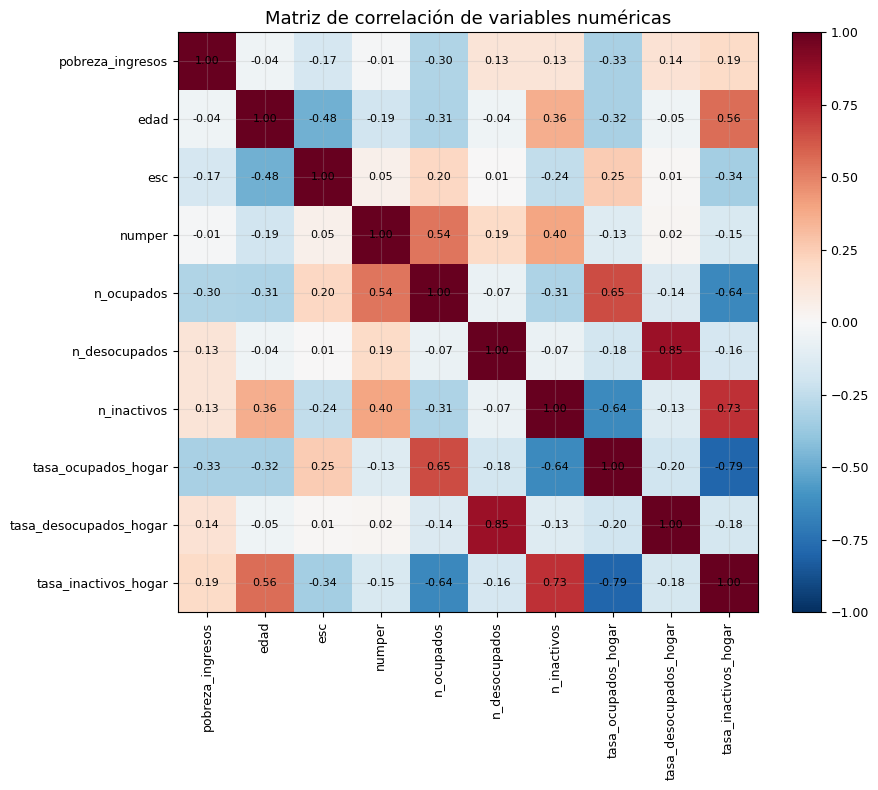


Pares con correlación absoluta mayor o igual a 0.70


,variable_1,variable_2,correlacion
0,n_desocupados,tasa_desocupados_hogar,0.854
1,n_inactivos,tasa_inactivos_hogar,0.732
2,tasa_ocupados_hogar,tasa_inactivos_hogar,-0.793


In [7]:
# ============================================================
# BLOQUE 7: Correlaciones entre variables numéricas
# ============================================================

corr = df_eda[variables_numericas_modelo].corr()

mostrar_titulo("Matriz de correlación")
display(corr.round(3))

corr_objetivo = corr["pobreza_ingresos"].drop("pobreza_ingresos").sort_values(
    key=lambda x: abs(x), ascending=False
)

mostrar_titulo("Correlación con pobreza_ingresos")
display(corr_objetivo.round(3).to_frame("correlacion"))

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.index)
ax.set_title("Matriz de correlación de variables numéricas")

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

pares_correlacion = []
for i in range(len(variables_numericas_modelo)):
    for j in range(i + 1, len(variables_numericas_modelo)):
        var1 = variables_numericas_modelo[i]
        var2 = variables_numericas_modelo[j]
        valor = corr.loc[var1, var2]
        if abs(valor) >= 0.70:
            pares_correlacion.append({"variable_1": var1, "variable_2": var2, "correlacion": round(valor, 3)})

mostrar_titulo("Pares con correlación absoluta mayor o igual a 0.70")
pares_correlacion = pd.DataFrame(pares_correlacion)
if pares_correlacion.empty:
    print("No se encontraron pares con correlación alta.")
else:
    display(pares_correlacion)



Asociación entre variables categóricas y pobreza_ingresos


,variable,n_categorias,chi2,gl,valor_p,v_cramer
0,contrato,4,"4,641.646",3,0.000,0.243
1,cotiza,3,"4,634.948",2,0.000,0.243
2,activ,3,"3,935.104",2,0.000,0.224
3,tipohogar,6,"1,852.511",5,0.000,0.153
4,ind_estado,3,"1,675.360",2,0.000,0.146
5,ecivil,8,"1,447.002",7,0.000,0.136
6,ten_viv_f,2,"1,304.735",1,0.000,0.129
7,ind_cal_glob,3,"1,115.570",2,0.000,0.119
8,region,16,"1,103.013",15,0.000,0.118
9,jefatura_mujer,2,974.362,1,0.000,0.111


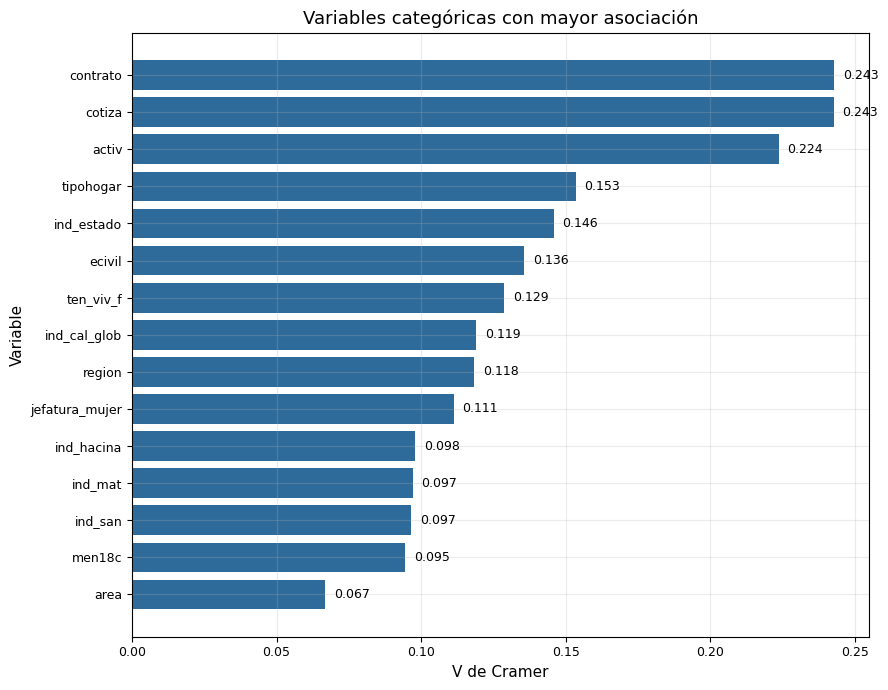


Tablas de pobreza para las variables categóricas más asociadas

Variable: contrato


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
contrato,,,,,
2.000,31583,12103,43686,27.700,55.540
0.000,3318,1153,4471,25.790,5.680
3.000,52,7,59,11.860,0.080
1.000,28106,2332,30438,7.660,38.700



Variable: cotiza


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
cotiza,,,,,
0.000,29713,12066,41779,28.880,53.120
2.000,155,57,212,26.890,0.270
1.000,33191,3472,36663,9.470,46.610



Variable: activ


...

,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
ecivil,,,,,
5.000,3976,1522,5498,27.680,6.990
8.000,13439,4800,18239,26.320,23.190
7.000,6429,1925,8354,23.040,10.620
6.000,3651,1035,4686,22.090,5.960
2.000,12013,2555,14568,17.540,18.520
4.000,116,20,136,14.710,0.170
1.000,23123,3695,26818,13.780,34.100
3.000,312,43,355,12.110,0.450



Variable: ten_viv_f


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
ten_viv_f,,,,,
2,11948,5028,16976,29.620,21.580
1,51111,10567,61678,17.130,78.420



Variable: ind_cal_glob


,No pobreza,Pobreza,Total,Porcentaje pobreza,Porcentaje del total
ind_cal_glob,,,,,
3,166,134,300,44.670,0.380
2,5553,2715,8268,32.840,10.510
1,57340,12746,70086,18.190,89.110


In [11]:
# ============================================================
# BLOQUE 8: Asociación bivariada de variables categóricas
# ============================================================

resultados_categoricas = []

for var in variables_categoricas:
    tabla = pd.crosstab(df_eda[var], df_eda["pobreza_ingresos"])
    v_cramer, chi2, p_valor, gl = cramer_v(tabla)
    resultados_categoricas.append({
        "variable": var,
        "n_categorias": df_eda[var].nunique(),
        "chi2": chi2,
        "gl": gl,
        "valor_p": p_valor,
        "v_cramer": v_cramer
    })

resultados_categoricas = (
    pd.DataFrame(resultados_categoricas)
    .sort_values("v_cramer", ascending=False)
    .reset_index(drop=True)
)

mostrar_titulo("Asociación entre variables categóricas y pobreza_ingresos")
display(resultados_categoricas.round({"chi2": 3, "v_cramer": 3}))

fig, ax = plt.subplots(figsize=(9, 7))
top_v = resultados_categoricas.head(15).iloc[::-1]
ax.barh(top_v["variable"], top_v["v_cramer"], color=PALETA["azul"])
ax.set_title("Variables categóricas con mayor asociación")
ax.set_xlabel("V de Cramer")
ax.set_ylabel("Variable")

for i, v in enumerate(top_v["v_cramer"]):
    ax.text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=9)

plt.show()

mostrar_titulo("Tablas de pobreza para las variables categóricas más asociadas")
for var in resultados_categoricas.head(8)["variable"]:
    print(f"\nVariable: {var}")
    display(tabla_pobreza_categoria(df_eda, var))


## 3. Preparación para modelamiento

In [12]:
# ============================================================
# BLOQUE 9: Preparación de datos para modelamiento
# ============================================================

variable_objetivo = "pobreza_ingresos"
y = df_eda[variable_objetivo].astype(int)
X = df_eda[variables_predictoras_logistica].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

preprocesamiento_logistica = ColumnTransformer(
    transformers=[
        ("numericas", StandardScaler(), variables_numericas_logistica),
        ("categoricas", OneHotEncoder(handle_unknown="ignore"), variables_categoricas_logistica)
    ]
)

mostrar_titulo("Preparación de datos")
print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)
print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)
print("Variables excluidas por redundancia laboral: n_ocupados, n_desocupados, n_inactivos")

tabla_distribucion = pd.DataFrame({
    "Train (%)": (y_train.value_counts(normalize=True).sort_index() * 100).round(2),
    "Test (%)": (y_test.value_counts(normalize=True).sort_index() * 100).round(2)
})
tabla_distribucion.index = ["No pobreza", "Pobreza"]

display(tabla_distribucion)



Preparación de datos
Dimensión de X: (78654, 25)
Dimensión de y: (78654,)
Entrenamiento: (55057, 25)
Prueba: (23597, 25)
Variables excluidas por redundancia laboral: n_ocupados, n_desocupados, n_inactivos


,Train (%),Test (%)
No pobreza,80.170,80.170
Pobreza,19.830,19.830


## 4. Regresión logística

In [13]:
# ============================================================
# BLOQUE 10: Ajuste de regresiones logísticas
# ============================================================

modelo_logistico_base = Pipeline(
    steps=[
        ("preprocesamiento", preprocesamiento_logistica),
        ("modelo", LogisticRegression(max_iter=1000, random_state=SEED))
    ]
)

modelo_logistico_balanceado = Pipeline(
    steps=[
        ("preprocesamiento", preprocesamiento_logistica),
        ("modelo", LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced"))
    ]
)

modelo_logistico_base.fit(X_train, y_train)
modelo_logistico_balanceado.fit(X_train, y_train)

# Predicciones de clase y probabilidad
y_pred_base = modelo_logistico_base.predict(X_test)
y_prob_base = modelo_logistico_base.predict_proba(X_test)[:, 1]

y_pred_balanceado = modelo_logistico_balanceado.predict(X_test)
y_prob_balanceado = modelo_logistico_balanceado.predict_proba(X_test)[:, 1]

print("Modelos ajustados correctamente.")


Modelos ajustados correctamente.



Comparación de métricas


,modelo,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Regresión logística base,0.837,0.646,0.395,0.490,0.849,0.588
1,Regresión logística balanceada,0.760,0.440,0.780,0.563,0.850,0.583



Matriz de confusión - Regresión logística base


,Predicho: No pobreza,Predicho: Pobreza
Real: No pobreza,17903,1015
Real: Pobreza,2829,1850


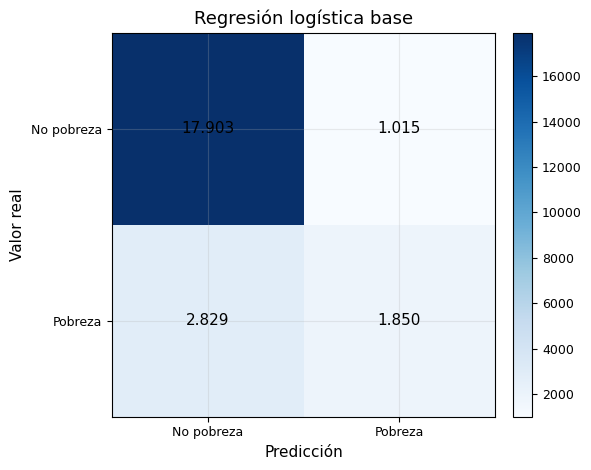


Matriz de confusión - Regresión logística balanceada


,Predicho: No pobreza,Predicho: Pobreza
Real: No pobreza,14276,4642
Real: Pobreza,1031,3648


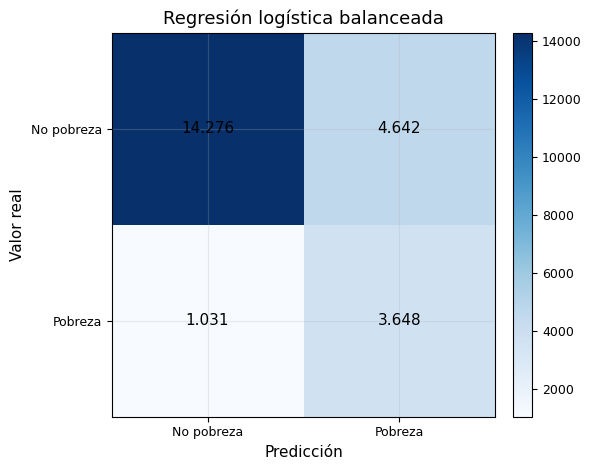


Reporte de clasificación - modelo base
              precision    recall  f1-score   support

  No pobreza       0.86      0.95      0.90     18918
     Pobreza       0.65      0.40      0.49      4679

    accuracy                           0.84     23597
   macro avg       0.75      0.67      0.70     23597
weighted avg       0.82      0.84      0.82     23597


Reporte de clasificación - modelo balanceado
              precision    recall  f1-score   support

  No pobreza       0.93      0.75      0.83     18918
     Pobreza       0.44      0.78      0.56      4679

    accuracy                           0.76     23597
   macro avg       0.69      0.77      0.70     23597
weighted avg       0.83      0.76      0.78     23597



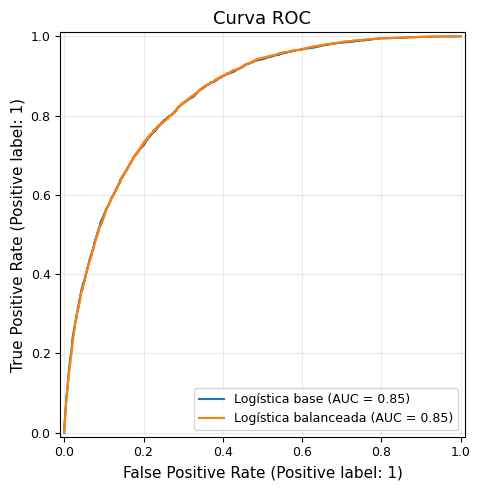

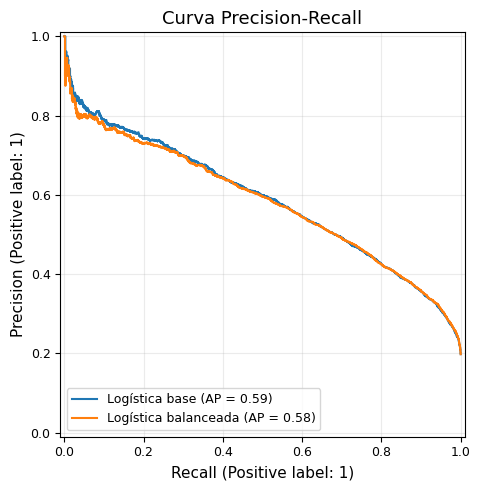

In [14]:
# ============================================================
# BLOQUE 11: Evaluación de regresiones logísticas
# ============================================================

metricas_base = evaluar_modelo("Regresión logística base", y_test, y_pred_base, y_prob_base)
metricas_balanceado = evaluar_modelo("Regresión logística balanceada", y_test, y_pred_balanceado, y_prob_balanceado)

tabla_metricas = pd.DataFrame([metricas_base, metricas_balanceado])
for col in ["accuracy", "precision", "recall", "f1_score", "roc_auc", "pr_auc"]:
    tabla_metricas[col] = tabla_metricas[col].round(3)

mostrar_titulo("Comparación de métricas")
display(tabla_metricas)

matriz_base = mostrar_matriz_confusion("Regresión logística base", y_test, y_pred_base)
matriz_balanceado = mostrar_matriz_confusion("Regresión logística balanceada", y_test, y_pred_balanceado)

mostrar_titulo("Reporte de clasificación - modelo base")
print(classification_report(y_test, y_pred_base, target_names=["No pobreza", "Pobreza"], zero_division=0))

mostrar_titulo("Reporte de clasificación - modelo balanceado")
print(classification_report(y_test, y_pred_balanceado, target_names=["No pobreza", "Pobreza"], zero_division=0))

# Curva ROC
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_prob_base, name="Logística base", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_balanceado, name="Logística balanceada", ax=ax)
ax.set_title("Curva ROC")
ax.grid(alpha=0.25)
plt.show()

# Curva Precision-Recall
fig, ax = plt.subplots(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(y_test, y_prob_base, name="Logística base", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, y_prob_balanceado, name="Logística balanceada", ax=ax)
ax.set_title("Curva Precision-Recall")
ax.grid(alpha=0.25)
plt.show()


In [ ]:
# ============================================================
# BLOQUE 12: Regresión logística interpretativa y odds ratios
# ============================================================

preprocesamiento_interpretacion = ColumnTransformer(
    transformers=[
        ("numericas", StandardScaler(), variables_numericas_logistica),
        ("categoricas", OneHotEncoder(handle_unknown="ignore", drop="first"), variables_categoricas_logistica)
    ]
)

modelo_logistico_interpretacion = Pipeline(
    steps=[
        ("preprocesamiento", preprocesamiento_interpretacion),
        ("modelo", LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced"))
    ]
)

modelo_logistico_interpretacion.fit(X_train, y_train)

y_pred_interpretacion = modelo_logistico_interpretacion.predict(X_test)
y_prob_interpretacion = modelo_logistico_interpretacion.predict_proba(X_test)[:, 1]

metricas_interpretacion = evaluar_modelo(
    "Regresión logística balanceada interpretativa",
    y_test,
    y_pred_interpretacion,
    y_prob_interpretacion
)

tabla_metricas_interpretacion = pd.DataFrame([metricas_interpretacion])
for col in ["accuracy", "precision", "recall", "f1_score", "roc_auc", "pr_auc"]:
    tabla_metricas_interpretacion[col] = tabla_metricas_interpretacion[col].round(3)

mostrar_titulo("Métricas del modelo final")
display(tabla_metricas_interpretacion)

tabla_matriz_interpretacion = mostrar_matriz_confusion(
    "Regresión logística balanceada interpretativa",
    y_test,
    y_pred_interpretacion
)

preprocesador_interpretacion = modelo_logistico_interpretacion.named_steps["preprocesamiento"]
encoder_interpretacion = preprocesador_interpretacion.named_transformers_["categoricas"]
modelo_final_interpretacion = modelo_logistico_interpretacion.named_steps["modelo"]

# Categorías de referencia
tabla_referencias = pd.DataFrame({
    "variable": variables_categoricas_logistica,
    "categoria_referencia": [categorias[0] for categorias in encoder_interpretacion.categories_]
})

mostrar_titulo("Categorías de referencia")
display(tabla_referencias)

# Coeficientes y odds ratios
nombres_numericas = variables_numericas_logistica
nombres_categoricas = encoder_interpretacion.get_feature_names_out(variables_categoricas_logistica)
nombres_variables_transformadas = list(nombres_numericas) + list(nombres_categoricas)
coeficientes = modelo_final_interpretacion.coef_[0]

tabla_or = pd.DataFrame({
    "variable_transformada": nombres_variables_transformadas,
    "coeficiente": coeficientes
})

def identificar_variable_original(nombre):
    if nombre in variables_numericas_logistica:
        return nombre
    for var in variables_categoricas_logistica:
        if nombre.startswith(var + "_"):
            return var
    return nombre

tabla_or["variable_original"] = tabla_or["variable_transformada"].apply(identificar_variable_original)
tabla_or["odds_ratio"] = np.exp(tabla_or["coeficiente"])
tabla_or["coef_abs"] = tabla_or["coeficiente"].abs()

tabla_or_ordenada = tabla_or.sort_values("coef_abs", ascending=False)

mostrar_titulo("Coeficientes y odds ratios más relevantes")
display(tabla_or_ordenada[["variable_transformada", "variable_original", "coeficiente", "odds_ratio", "coef_abs"]].head(25).round(4))

mostrar_titulo("Variables/categorías asociadas a mayor probabilidad estimada de pobreza")
display(tabla_or.sort_values("coeficiente", ascending=False)[["variable_transformada", "variable_original", "coeficiente", "odds_ratio"]].head(15).round(4))

mostrar_titulo("Variables/categorías asociadas a menor probabilidad estimada de pobreza")
display(tabla_or.sort_values("coeficiente", ascending=True)[["variable_transformada", "variable_original", "coeficiente", "odds_ratio"]].head(15).round(4))

# Gráfico de coeficientes más relevantes
top_or = tabla_or_ordenada.head(20).copy().iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_or["variable_transformada"], top_or["coeficiente"], color=np.where(top_or["coeficiente"] > 0, PALETA["naranjo"], PALETA["azul"]))
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Coeficientes más relevantes del modelo final")
ax.set_xlabel("Coeficiente logístico")
ax.set_ylabel("Variable transformada")
plt.show()


In [ ]:
# ============================================================
# BLOQUE 13: Escritura del modelo logístico con betas
# ============================================================

# ------------------------------------------------------------
# 1. Extraer intercepto y coeficientes
# ------------------------------------------------------------

modelo_final_interpretacion = modelo_logistico_interpretacion.named_steps["modelo"]

beta_0 = modelo_final_interpretacion.intercept_[0]

tabla_betas = tabla_or.copy()
tabla_betas = tabla_betas.sort_values("coef_abs", ascending=False).reset_index(drop=True)

print("INTERCEPTO DEL MODELO")
print("="*70)
print(f"beta_0 = {beta_0:.6f}")

print("\nBETAS DEL MODELO")
print("="*70)
display(
    tabla_betas[
        ["variable_transformada", "variable_original", "coeficiente", "odds_ratio"]
    ].round(6)
)

# ------------------------------------------------------------
# 2. Crear ecuación completa en texto
# ------------------------------------------------------------

terminos = []

for _, fila in tabla_or.iterrows():
    beta = fila["coeficiente"]
    variable = fila["variable_transformada"]

    if beta >= 0:
        termino = f"+ {beta:.6f}*{variable}"
    else:
        termino = f"- {abs(beta):.6f}*{variable}"

    terminos.append(termino)

ecuacion_modelo = "logit(pobreza_ingresos=1) = "
ecuacion_modelo += f"{beta_0:.6f} "
ecuacion_modelo += " ".join(terminos)

print("\nECUACIÓN COMPLETA DEL MODELO")
print("="*70)
print(ecuacion_modelo)

# ------------------------------------------------------------
# 3. Nota de interpretación
# ------------------------------------------------------------

print("\nNOTA")
print("="*70)
print("Las variables numéricas fueron estandarizadas con StandardScaler().")
print("Por eso, sus betas se interpretan por aumento de una desviación estándar,")
print("no por una unidad original de la variable.")


In [ ]:
# ============================================================
# BLOQUE 14: Validación cruzada de la regresión logística
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

metricas_cv = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

resultados_cv = cross_validate(
    modelo_logistico_interpretacion,
    X_train,
    y_train,
    cv=cv,
    scoring=metricas_cv,
    n_jobs=-1,
    return_train_score=False
)

tabla_cv = pd.DataFrame({
    "metrica": ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"],
    "media_cv": [
        resultados_cv["test_accuracy"].mean(),
        resultados_cv["test_precision"].mean(),
        resultados_cv["test_recall"].mean(),
        resultados_cv["test_f1"].mean(),
        resultados_cv["test_roc_auc"].mean(),
        resultados_cv["test_pr_auc"].mean()
    ],
    "desviacion_cv": [
        resultados_cv["test_accuracy"].std(),
        resultados_cv["test_precision"].std(),
        resultados_cv["test_recall"].std(),
        resultados_cv["test_f1"].std(),
        resultados_cv["test_roc_auc"].std(),
        resultados_cv["test_pr_auc"].std()
    ]
}).round(3)

mostrar_titulo("Validación cruzada del modelo final")
display(tabla_cv)

tabla_test = pd.DataFrame({
    "metrica": ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"],
    "resultado_test": [
        metricas_interpretacion["accuracy"],
        metricas_interpretacion["precision"],
        metricas_interpretacion["recall"],
        metricas_interpretacion["f1_score"],
        metricas_interpretacion["roc_auc"],
        metricas_interpretacion["pr_auc"]
    ]
}).round(3)

tabla_comparacion_cv_test = tabla_cv.merge(tabla_test, on="metrica")

mostrar_titulo("Comparación entre validación cruzada y test")
display(tabla_comparacion_cv_test)


## 5. Selección parsimoniosa

In [ ]:
# ============================================================
# BLOQUE 15: Selección forward de variables con validación cruzada
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ------------------------------------------------------------
# 1. Variables candidatas
# ------------------------------------------------------------

variables_candidatas_forward = [
    "edad",
    "esc",
    "numper",
    "tasa_ocupados_hogar",
    "tasa_desocupados_hogar",
    "tasa_inactivos_hogar",
    "jefatura_mujer",
    "ecivil",
    "activ",
    "contrato",
    "cotiza",
    "disc_wg",
    "pueblos_indigenas",
    "nacido_fuera_chile",
    "tipohogar",
    "men18c",
    "may60c",
    "region",
    "area",
    "ind_hacina",
    "ind_san",
    "ind_mat",
    "ind_estado",
    "ind_cal_glob",
    "ten_viv_f"
]

# ------------------------------------------------------------
# 2. Clasificar variables numéricas y categóricas
# ------------------------------------------------------------

variables_numericas_base = [
    "edad",
    "esc",
    "numper",
    "tasa_ocupados_hogar",
    "tasa_desocupados_hogar",
    "tasa_inactivos_hogar"
]

variables_categoricas_base = [
    var for var in variables_candidatas_forward
    if var not in variables_numericas_base
]

# ------------------------------------------------------------
# 3. Función para construir modelo según variables seleccionadas
# ------------------------------------------------------------

def crear_modelo_logistico_balanceado(lista_variables):

    numericas = [
        var for var in lista_variables
        if var in variables_numericas_base
    ]

    categoricas = [
        var for var in lista_variables
        if var in variables_categoricas_base
    ]

    transformadores = []

    if len(numericas) > 0:
        transformadores.append(
            ("numericas", StandardScaler(), numericas)
        )

    if len(categoricas) > 0:
        transformadores.append(
            ("categoricas", OneHotEncoder(handle_unknown="ignore", drop="first"), categoricas)
        )

    preprocesamiento = ColumnTransformer(
        transformers=transformadores
    )

    modelo = Pipeline(
        steps=[
            ("preprocesamiento", preprocesamiento),
            ("modelo", LogisticRegression(
                max_iter=1000,
                random_state=SEED,
                class_weight="balanced"
            ))
        ]
    )

    return modelo

# ------------------------------------------------------------
# 4. Validación cruzada para selección
# ------------------------------------------------------------

cv_forward = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED
)

# ------------------------------------------------------------
# 5. Parámetros de selección
# ------------------------------------------------------------

max_variables = 12
mejora_minima = 0.003

variables_seleccionadas = []
variables_restantes = variables_candidatas_forward.copy()

mejor_f1_actual = 0

historial_forward = []

print("SELECCIÓN FORWARD CON VALIDACIÓN CRUZADA")
print("="*80)

# ------------------------------------------------------------
# 6. Proceso forward
# ------------------------------------------------------------

while len(variables_restantes) > 0 and len(variables_seleccionadas) < max_variables:

    resultados_paso = []

    for variable in variables_restantes:

        variables_prueba = variables_seleccionadas + [variable]

        modelo_prueba = crear_modelo_logistico_balanceado(variables_prueba)

        scores = cross_val_score(
            modelo_prueba,
            X_train[variables_prueba],
            y_train,
            cv=cv_forward,
            scoring="f1",
            n_jobs=-1
        )

        resultados_paso.append({
            "variable_candidata": variable,
            "f1_cv_medio": scores.mean(),
            "f1_cv_std": scores.std()
        })

    resultados_paso = pd.DataFrame(resultados_paso)
    resultados_paso = resultados_paso.sort_values(
        "f1_cv_medio",
        ascending=False
    ).reset_index(drop=True)

    mejor_variable = resultados_paso.loc[0, "variable_candidata"]
    mejor_f1_paso = resultados_paso.loc[0, "f1_cv_medio"]
    mejora = mejor_f1_paso - mejor_f1_actual

    print("\n" + "-"*80)
    print(f"Paso {len(variables_seleccionadas) + 1}")
    print(f"Mejor variable candidata: {mejor_variable}")
    print(f"F1 CV medio: {mejor_f1_paso:.4f}")
    print(f"Mejora respecto al paso anterior: {mejora:.4f}")

    historial_forward.append({
        "paso": len(variables_seleccionadas) + 1,
        "variable_agregada": mejor_variable,
        "f1_cv_medio": mejor_f1_paso,
        "f1_cv_std": resultados_paso.loc[0, "f1_cv_std"],
        "mejora": mejora,
        "variables_modelo": variables_seleccionadas + [mejor_variable]
    })

    if len(variables_seleccionadas) == 0 or mejora >= mejora_minima:
        variables_seleccionadas.append(mejor_variable)
        variables_restantes.remove(mejor_variable)
        mejor_f1_actual = mejor_f1_paso

        print("Variable agregada al modelo.")
    else:
        print("La mejora es menor al criterio definido. Se detiene la selección.")
        break

# ------------------------------------------------------------
# 7. Resultados finales de la selección
# ------------------------------------------------------------

historial_forward = pd.DataFrame(historial_forward)

print("\n" + "="*80)
print("VARIABLES SELECCIONADAS FINALMENTE")
print("="*80)

for i, var in enumerate(variables_seleccionadas, start=1):
    print(f"{i}. {var}")

print("\nHistorial de selección:")
display(
    historial_forward[
        ["paso", "variable_agregada", "f1_cv_medio", "f1_cv_std", "mejora"]
    ].round(4)
)


In [ ]:
# ============================================================
# BLOQUE 16: Evaluación de regresión logística parsimoniosa
# ============================================================

# ------------------------------------------------------------
# 1. Variables seleccionadas por forward
# ------------------------------------------------------------

variables_parsimonioso_forward = variables_seleccionadas.copy()

# Modelo extendido agregando escolaridad, por cercanía al criterio
variables_parsimonioso_extendido = variables_seleccionadas.copy()

if "esc" not in variables_parsimonioso_extendido:
    variables_parsimonioso_extendido.append("esc")

print("VARIABLES MODELO PARSIMONIOSO FORWARD")
print("="*70)
for var in variables_parsimonioso_forward:
    print("-", var)

print("\nVARIABLES MODELO PARSIMONIOSO EXTENDIDO")
print("="*70)
for var in variables_parsimonioso_extendido:
    print("-", var)

# ------------------------------------------------------------
# 2. Función para ajustar y evaluar un modelo
# ------------------------------------------------------------

def ajustar_evaluar_modelo(nombre_modelo, variables_modelo):

    X_train_modelo = X_train[variables_modelo].copy()
    X_test_modelo = X_test[variables_modelo].copy()

    modelo = crear_modelo_logistico_balanceado(variables_modelo)

    modelo.fit(X_train_modelo, y_train)

    y_pred = modelo.predict(X_test_modelo)
    y_prob = modelo.predict_proba(X_test_modelo)[:, 1]

    metricas = {
        "modelo": nombre_modelo,
        "n_variables_originales": len(variables_modelo),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "pr_auc": average_precision_score(y_test, y_prob)
    }

    matriz = confusion_matrix(y_test, y_pred)

    tabla_matriz = pd.DataFrame(
        matriz,
        index=["Real: No pobreza", "Real: Pobreza"],
        columns=["Predicho: No pobreza", "Predicho: Pobreza"]
    )

    return modelo, metricas, tabla_matriz, y_pred, y_prob

# ------------------------------------------------------------
# 3. Ajustar modelos parsimoniosos
# ------------------------------------------------------------

modelo_forward, metricas_forward, matriz_forward, y_pred_forward, y_prob_forward = ajustar_evaluar_modelo(
    "Logística parsimoniosa forward",
    variables_parsimonioso_forward
)

modelo_extendido, metricas_extendido, matriz_extendido, y_pred_extendido, y_prob_extendido = ajustar_evaluar_modelo(
    "Logística parsimoniosa extendida",
    variables_parsimonioso_extendido
)

# ------------------------------------------------------------
# 4. Comparar con modelo completo
# ------------------------------------------------------------

metricas_completo = {
    "modelo": "Logística balanceada completa",
    "n_variables_originales": len(variables_predictoras_logistica),
    "accuracy": metricas_interpretacion["accuracy"],
    "precision": metricas_interpretacion["precision"],
    "recall": metricas_interpretacion["recall"],
    "f1_score": metricas_interpretacion["f1_score"],
    "roc_auc": metricas_interpretacion["roc_auc"],
    "pr_auc": metricas_interpretacion["pr_auc"]
}

tabla_comparacion_modelos = pd.DataFrame([
    metricas_completo,
    metricas_forward,
    metricas_extendido
])

for col in ["accuracy", "precision", "recall", "f1_score", "roc_auc", "pr_auc"]:
    tabla_comparacion_modelos[col] = tabla_comparacion_modelos[col].round(3)

print("\nCOMPARACIÓN DE MODELOS")
print("="*70)
display(tabla_comparacion_modelos)

# ------------------------------------------------------------
# 5. Matrices de confusión
# ------------------------------------------------------------

print("\nMATRIZ DE CONFUSIÓN - MODELO PARSIMONIOSO FORWARD")
print("="*70)
display(matriz_forward)

print("\nMATRIZ DE CONFUSIÓN - MODELO PARSIMONIOSO EXTENDIDO")
print("="*70)
display(matriz_extendido)

# ------------------------------------------------------------
# 6. Interpretación inicial
# ------------------------------------------------------------

print("\nINTERPRETACIÓN INICIAL")
print("="*70)

print("El modelo parsimonioso forward corresponde al resultado directo de la selección por validación cruzada.")
print("El modelo extendido agrega escolaridad porque quedó muy cerca del criterio de entrada y tiene justificación teórica.")
print("La decisión final debe considerar desempeño predictivo y parsimonia.")
print("Si el modelo parsimonioso pierde poco desempeño respecto al completo, puede ser preferible por ser más simple e interpretable.")


## 6. Modelos alternativos

In [ ]:
# ============================================================
# BLOQUE 17: Árbol de decisión y Random Forest inicial
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ------------------------------------------------------------
# 1. Variables utilizadas
# ------------------------------------------------------------

variables_modelos_arboles = variables_predictoras_logistica.copy()

X_train_arboles = X_train[variables_modelos_arboles].copy()
X_test_arboles = X_test[variables_modelos_arboles].copy()

# Variables numéricas utilizadas en la regresión logística
variables_numericas_arboles = [
    "edad",
    "esc",
    "numper",
    "tasa_ocupados_hogar",
    "tasa_desocupados_hogar",
    "tasa_inactivos_hogar"
]

# Variables categóricas
variables_categoricas_arboles = [
    var for var in variables_modelos_arboles
    if var not in variables_numericas_arboles
]

print("VARIABLES USADAS EN LOS MODELOS ALTERNATIVOS")
print("="*70)
print("Total variables originales:", len(variables_modelos_arboles))
print("\nVariables numéricas:")
for var in variables_numericas_arboles:
    print("-", var)

print("\nVariables categóricas:")
for var in variables_categoricas_arboles:
    print("-", var)

# ------------------------------------------------------------
# 2. Preprocesamiento
# ------------------------------------------------------------
# Los árboles no necesitan estandarización.
# Las variables numéricas pasan directo y las categóricas se codifican con OneHotEncoder.

preprocesamiento_arboles = ColumnTransformer(
    transformers=[
        ("numericas", "passthrough", variables_numericas_arboles),
        ("categoricas", OneHotEncoder(handle_unknown="ignore"), variables_categoricas_arboles)
    ]
)

# ------------------------------------------------------------
# 3. Árbol de decisión
# ------------------------------------------------------------

modelo_arbol_decision = Pipeline(
    steps=[
        ("preprocesamiento", preprocesamiento_arboles),
        ("modelo", DecisionTreeClassifier(
            max_depth=6,
            min_samples_leaf=100,
            class_weight="balanced",
            random_state=SEED
        ))
    ]
)

modelo_arbol_decision.fit(X_train_arboles, y_train)

y_pred_arbol = modelo_arbol_decision.predict(X_test_arboles)
y_prob_arbol = modelo_arbol_decision.predict_proba(X_test_arboles)[:, 1]

# ------------------------------------------------------------
# 4. Random Forest
# ------------------------------------------------------------

modelo_random_forest = Pipeline(
    steps=[
        ("preprocesamiento", preprocesamiento_arboles),
        ("modelo", RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=50,
            class_weight="balanced_subsample",
            random_state=SEED,
            n_jobs=-1
        ))
    ]
)

modelo_random_forest.fit(X_train_arboles, y_train)

y_pred_rf = modelo_random_forest.predict(X_test_arboles)
y_prob_rf = modelo_random_forest.predict_proba(X_test_arboles)[:, 1]

# ------------------------------------------------------------
# 5. Función para calcular métricas
# ------------------------------------------------------------

def calcular_metricas_clasificacion(nombre_modelo, y_real, y_pred, y_prob, n_variables):

    metricas = {
        "modelo": nombre_modelo,
        "n_variables_originales": n_variables,
        "accuracy": accuracy_score(y_real, y_pred),
        "precision": precision_score(y_real, y_pred, zero_division=0),
        "recall": recall_score(y_real, y_pred, zero_division=0),
        "f1_score": f1_score(y_real, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_real, y_prob),
        "pr_auc": average_precision_score(y_real, y_prob)
    }

    return metricas

metricas_arbol = calcular_metricas_clasificacion(
    "Árbol de decisión",
    y_test,
    y_pred_arbol,
    y_prob_arbol,
    len(variables_modelos_arboles)
)

metricas_rf = calcular_metricas_clasificacion(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf,
    len(variables_modelos_arboles)
)

# ------------------------------------------------------------
# 6. Comparación inicial de modelos
# ------------------------------------------------------------

tabla_comparacion_arboles = pd.DataFrame([
    metricas_arbol,
    metricas_rf
])

for col in ["accuracy", "precision", "recall", "f1_score", "roc_auc", "pr_auc"]:
    tabla_comparacion_arboles[col] = tabla_comparacion_arboles[col].round(3)

print("\nCOMPARACIÓN MODELOS ALTERNATIVOS")
print("="*70)
display(tabla_comparacion_arboles)

# ------------------------------------------------------------
# 7. Matrices de confusión
# ------------------------------------------------------------

matriz_arbol = pd.DataFrame(
    confusion_matrix(y_test, y_pred_arbol),
    index=["Real: No pobreza", "Real: Pobreza"],
    columns=["Predicho: No pobreza", "Predicho: Pobreza"]
)

matriz_rf = pd.DataFrame(
    confusion_matrix(y_test, y_pred_rf),
    index=["Real: No pobreza", "Real: Pobreza"],
    columns=["Predicho: No pobreza", "Predicho: Pobreza"]
)

print("\nMATRIZ DE CONFUSIÓN - ÁRBOL DE DECISIÓN")
print("="*70)
display(matriz_arbol)

print("\nMATRIZ DE CONFUSIÓN - RANDOM FOREST")
print("="*70)
display(matriz_rf)


In [ ]:
# ============================================================
# BLOQUE 18: Validación cruzada de modelos basados en árboles
# ============================================================

from sklearn.model_selection import cross_validate, StratifiedKFold

# ------------------------------------------------------------
# 1. Validación cruzada estratificada
# ------------------------------------------------------------

cv_arboles = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED
)

scoring_modelos = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

# ------------------------------------------------------------
# 2. Función para resumir validación cruzada
# ------------------------------------------------------------

def resumen_validacion_cruzada(nombre_modelo, modelo, X_train_modelo, y_train):

    resultados_cv = cross_validate(
        modelo,
        X_train_modelo,
        y_train,
        cv=cv_arboles,
        scoring=scoring_modelos,
        n_jobs=-1
    )

    resumen = {
        "modelo": nombre_modelo,
        "accuracy_cv": resultados_cv["test_accuracy"].mean(),
        "accuracy_sd": resultados_cv["test_accuracy"].std(),
        "precision_cv": resultados_cv["test_precision"].mean(),
        "precision_sd": resultados_cv["test_precision"].std(),
        "recall_cv": resultados_cv["test_recall"].mean(),
        "recall_sd": resultados_cv["test_recall"].std(),
        "f1_cv": resultados_cv["test_f1"].mean(),
        "f1_sd": resultados_cv["test_f1"].std(),
        "roc_auc_cv": resultados_cv["test_roc_auc"].mean(),
        "roc_auc_sd": resultados_cv["test_roc_auc"].std(),
        "pr_auc_cv": resultados_cv["test_pr_auc"].mean(),
        "pr_auc_sd": resultados_cv["test_pr_auc"].std()
    }

    return resumen

# ------------------------------------------------------------
# 3. Validación cruzada de modelos alternativos
# ------------------------------------------------------------

cv_arbol = resumen_validacion_cruzada(
    "Árbol de decisión",
    modelo_arbol_decision,
    X_train_arboles,
    y_train
)

cv_rf = resumen_validacion_cruzada(
    "Random Forest",
    modelo_random_forest,
    X_train_arboles,
    y_train
)

tabla_cv_arboles = pd.DataFrame([cv_arbol, cv_rf])

columnas_redondear = [
    "accuracy_cv", "accuracy_sd",
    "precision_cv", "precision_sd",
    "recall_cv", "recall_sd",
    "f1_cv", "f1_sd",
    "roc_auc_cv", "roc_auc_sd",
    "pr_auc_cv", "pr_auc_sd"
]

for col in columnas_redondear:
    tabla_cv_arboles[col] = tabla_cv_arboles[col].round(3)

print("VALIDACIÓN CRUZADA - MODELOS ALTERNATIVOS")
print("="*70)
display(tabla_cv_arboles)


In [ ]:
# ============================================================
# BLOQUE 19: Visualización parcial del árbol de decisión
# ============================================================

# ============================================================
# Visualización parcial del árbol de decisión
# ============================================================

from sklearn.tree import plot_tree

# ------------------------------------------------------------
# 1. Extraer árbol entrenado y preprocesador
# ------------------------------------------------------------

arbol_final = modelo_arbol_decision.named_steps["modelo"]
preprocesador_arbol = modelo_arbol_decision.named_steps["preprocesamiento"]

# ------------------------------------------------------------
# 2. Recuperar nombres de variables después del preprocesamiento
# ------------------------------------------------------------

nombres_numericas_arbol = variables_numericas_arboles

ohe_arbol = preprocesador_arbol.named_transformers_["categoricas"]

nombres_categoricas_arbol = list(
    ohe_arbol.get_feature_names_out(variables_categoricas_arboles)
)

nombres_variables_arbol = nombres_numericas_arbol + nombres_categoricas_arbol

# ------------------------------------------------------------
# 3. Graficar solo los primeros niveles del árbol
# ------------------------------------------------------------

plt.figure(figsize=(24, 10))

plot_tree(
    arbol_final,
    feature_names=nombres_variables_arbol,
    class_names=["No pobreza", "Pobreza"],
    max_depth=2,          # Cambia a 3 si quieres ver más niveles
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Árbol de decisión simplificado: primeros niveles", fontsize=15)
plt.tight_layout()
plt.show()


## 7. Random Forest ajustado

In [ ]:
# ============================================================
# BLOQUE 20: Ajuste de hiperparámetros del Random Forest
# ============================================================

from sklearn.model_selection import GridSearchCV, StratifiedKFold

# ------------------------------------------------------------
# 1. Modelo base para búsqueda
# ------------------------------------------------------------

rf_busqueda = Pipeline(
    steps=[
        ("preprocesamiento", preprocesamiento_arboles),
        ("modelo", RandomForestClassifier(
            random_state=SEED,
            n_jobs=-1
        ))
    ]
)

# ------------------------------------------------------------
# 2. Grilla pequeña de hiperparámetros
# ------------------------------------------------------------

param_grid_rf = {
    "modelo__n_estimators": [200, 300],
    "modelo__max_depth": [10, 12, 14],
    "modelo__min_samples_leaf": [30, 50],
    "modelo__max_features": ["sqrt", "log2"],
    "modelo__class_weight": ["balanced_subsample"]
}

# ------------------------------------------------------------
# 3. Validación cruzada
# ------------------------------------------------------------

cv_rf_tuning = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED
)

scoring_rf = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

# ------------------------------------------------------------
# 4. Búsqueda de hiperparámetros
# ------------------------------------------------------------

grid_rf = GridSearchCV(
    estimator=rf_busqueda,
    param_grid=param_grid_rf,
    scoring=scoring_rf,
    refit="f1",
    cv=cv_rf_tuning,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)

grid_rf.fit(X_train_arboles, y_train)

# ------------------------------------------------------------
# 5. Mejores hiperparámetros
# ------------------------------------------------------------

print("MEJORES HIPERPARÁMETROS RANDOM FOREST")
print("="*70)
print(grid_rf.best_params_)

print("\nMejor F1 promedio en validación cruzada:")
print(round(grid_rf.best_score_, 4))

# ------------------------------------------------------------
# 6. Resultados de la búsqueda
# ------------------------------------------------------------

resultados_grid_rf = pd.DataFrame(grid_rf.cv_results_)

columnas_resultados_rf = [
    "param_modelo__n_estimators",
    "param_modelo__max_depth",
    "param_modelo__min_samples_leaf",
    "param_modelo__max_features",
    "mean_test_accuracy",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1",
    "mean_test_roc_auc",
    "mean_test_pr_auc"
]

tabla_grid_rf = resultados_grid_rf[columnas_resultados_rf].copy()

tabla_grid_rf = tabla_grid_rf.sort_values(
    "mean_test_f1",
    ascending=False
).reset_index(drop=True)

for col in [
    "mean_test_accuracy",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1",
    "mean_test_roc_auc",
    "mean_test_pr_auc"
]:
    tabla_grid_rf[col] = tabla_grid_rf[col].round(3)

print("\nMEJORES COMBINACIONES SEGÚN F1")
print("="*70)
display(tabla_grid_rf.head(10))

# ------------------------------------------------------------
# 7. Evaluación del mejor Random Forest en el conjunto test
# ------------------------------------------------------------

modelo_random_forest_ajustado = grid_rf.best_estimator_

y_pred_rf_ajustado = modelo_random_forest_ajustado.predict(X_test_arboles)
y_prob_rf_ajustado = modelo_random_forest_ajustado.predict_proba(X_test_arboles)[:, 1]

metricas_rf_ajustado = calcular_metricas_clasificacion(
    "Random Forest ajustado",
    y_test,
    y_pred_rf_ajustado,
    y_prob_rf_ajustado,
    len(variables_modelos_arboles)
)

# ------------------------------------------------------------
# 8. Comparación Random Forest inicial vs ajustado
# ------------------------------------------------------------

tabla_comparacion_rf_ajuste = pd.DataFrame([
    metricas_rf,
    metricas_rf_ajustado
])

for col in ["accuracy", "precision", "recall", "f1_score", "roc_auc", "pr_auc"]:
    tabla_comparacion_rf_ajuste[col] = tabla_comparacion_rf_ajuste[col].round(3)

print("\nCOMPARACIÓN RANDOM FOREST INICIAL VS AJUSTADO")
print("="*70)
display(tabla_comparacion_rf_ajuste)

# ------------------------------------------------------------
# 9. Matriz de confusión del Random Forest ajustado
# ------------------------------------------------------------

matriz_rf_ajustado = pd.DataFrame(
    confusion_matrix(y_test, y_pred_rf_ajustado),
    index=["Real: No pobreza", "Real: Pobreza"],
    columns=["Predicho: No pobreza", "Predicho: Pobreza"]
)

print("\nMATRIZ DE CONFUSIÓN - RANDOM FOREST AJUSTADO")
print("="*70)
display(matriz_rf_ajustado)


## 8. Comparación final e interpretación del modelo final

In [ ]:
# ============================================================
# BLOQUE 21: Comparación final actualizada de modelos
# ============================================================

from sklearn.metrics import roc_curve, precision_recall_curve

# ------------------------------------------------------------
# 1. Tabla final actualizada
# ------------------------------------------------------------

tabla_comparacion_final_ajustada = pd.DataFrame([
    metricas_completo,
    metricas_extendido,
    metricas_arbol,
    metricas_rf_ajustado
])

columnas_finales = [
    "modelo",
    "n_variables_originales",
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "pr_auc"
]

tabla_comparacion_final_ajustada = tabla_comparacion_final_ajustada[columnas_finales]

for col in ["accuracy", "precision", "recall", "f1_score", "roc_auc", "pr_auc"]:
    tabla_comparacion_final_ajustada[col] = tabla_comparacion_final_ajustada[col].round(3)

print("COMPARACIÓN FINAL ACTUALIZADA DE MODELOS")
print("="*70)
display(tabla_comparacion_final_ajustada)

# ------------------------------------------------------------
# 2. Probabilidades estimadas de cada modelo
# ------------------------------------------------------------

modelos_probabilidades_final = {}

# Regresión logística completa
if "y_prob_interpretacion" in globals():
    modelos_probabilidades_final["Logística completa"] = y_prob_interpretacion
elif "y_prob_balanceado" in globals():
    modelos_probabilidades_final["Logística completa"] = y_prob_balanceado

# Regresión logística parsimoniosa extendida
modelos_probabilidades_final["Logística parsimoniosa extendida"] = y_prob_extendido

# Árbol de decisión
modelos_probabilidades_final["Árbol de decisión"] = y_prob_arbol

# Random Forest ajustado
modelos_probabilidades_final["Random Forest ajustado"] = y_prob_rf_ajustado

# ------------------------------------------------------------
# 3. Curva ROC comparativa actualizada
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

for nombre_modelo, y_prob in modelos_probabilidades_final.items():

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_modelo = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{nombre_modelo} (AUC = {auc_modelo:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Azar"
)

plt.title("Curva ROC comparativa", fontsize=14)
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Curva Precision-Recall comparativa actualizada
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

for nombre_modelo, y_prob in modelos_probabilidades_final.items():

    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
    ap_modelo = average_precision_score(y_test, y_prob)

    plt.plot(
        recall_curve,
        precision_curve,
        label=f"{nombre_modelo} (AP = {ap_modelo:.3f})"
    )

prevalencia_pobreza = y_test.mean()

plt.axhline(
    prevalencia_pobreza,
    linestyle="--",
    label=f"Prevalencia pobreza = {prevalencia_pobreza:.3f}"
)

plt.title("Curva Precision-Recall comparativa", fontsize=14)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Resumen final actualizado
# ------------------------------------------------------------

mejor_f1 = tabla_comparacion_final_ajustada.sort_values(
    "f1_score",
    ascending=False
).iloc[0]

mejor_auc = tabla_comparacion_final_ajustada.sort_values(
    "roc_auc",
    ascending=False
).iloc[0]

mejor_pr_auc = tabla_comparacion_final_ajustada.sort_values(
    "pr_auc",
    ascending=False
).iloc[0]

print("RESUMEN FINAL ACTUALIZADO")
print("="*70)
print(f"Mejor modelo según F1-score: {mejor_f1['modelo']} ({mejor_f1['f1_score']})")
print(f"Mejor modelo según ROC-AUC: {mejor_auc['modelo']} ({mejor_auc['roc_auc']})")
print(f"Mejor modelo según PR-AUC: {mejor_pr_auc['modelo']} ({mejor_pr_auc['pr_auc']})")


In [ ]:
# ============================================================
# BLOQUE 22: Importancia de variables del Random Forest ajustado
# ============================================================

# ------------------------------------------------------------
# 1. Extraer modelo ajustado y preprocesador
# ------------------------------------------------------------

rf_ajustado_final = modelo_random_forest_ajustado.named_steps["modelo"]
preprocesador_rf_ajustado = modelo_random_forest_ajustado.named_steps["preprocesamiento"]

# ------------------------------------------------------------
# 2. Recuperar nombres de variables transformadas
# ------------------------------------------------------------

nombres_numericas_rf_ajustado = variables_numericas_arboles

ohe_rf_ajustado = preprocesador_rf_ajustado.named_transformers_["categoricas"]

nombres_categoricas_rf_ajustado = list(
    ohe_rf_ajustado.get_feature_names_out(variables_categoricas_arboles)
)

nombres_variables_rf_ajustado = (
    nombres_numericas_rf_ajustado +
    nombres_categoricas_rf_ajustado
)

# ------------------------------------------------------------
# 3. Importancia a nivel de variable transformada
# ------------------------------------------------------------

tabla_importancia_rf_ajustado = pd.DataFrame({
    "variable_transformada": nombres_variables_rf_ajustado,
    "importancia": rf_ajustado_final.feature_importances_
})

tabla_importancia_rf_ajustado = tabla_importancia_rf_ajustado.sort_values(
    "importancia",
    ascending=False
).reset_index(drop=True)

tabla_importancia_rf_ajustado["importancia_pct"] = (
    100 *
    tabla_importancia_rf_ajustado["importancia"] /
    tabla_importancia_rf_ajustado["importancia"].sum()
)

print("IMPORTANCIA DE VARIABLES TRANSFORMADAS - RANDOM FOREST AJUSTADO")
print("="*70)

display(
    tabla_importancia_rf_ajustado.head(20).round(4)
)

# ------------------------------------------------------------
# 4. Recuperar variable original
# ------------------------------------------------------------

def obtener_variable_original_rf(nombre_variable):

    if nombre_variable in variables_numericas_arboles:
        return nombre_variable

    for var in variables_categoricas_arboles:
        if nombre_variable.startswith(var + "_"):
            return var

    return nombre_variable

tabla_importancia_rf_ajustado["variable_original"] = tabla_importancia_rf_ajustado[
    "variable_transformada"
].apply(obtener_variable_original_rf)

# ------------------------------------------------------------
# 5. Importancia agrupada por variable original
# ------------------------------------------------------------

tabla_importancia_original_rf_ajustado = (
    tabla_importancia_rf_ajustado
    .groupby("variable_original", as_index=False)
    .agg(importancia=("importancia", "sum"))
    .sort_values("importancia", ascending=False)
    .reset_index(drop=True)
)

tabla_importancia_original_rf_ajustado["importancia_pct"] = (
    100 *
    tabla_importancia_original_rf_ajustado["importancia"] /
    tabla_importancia_original_rf_ajustado["importancia"].sum()
)

print("\nIMPORTANCIA AGRUPADA POR VARIABLE ORIGINAL - RANDOM FOREST AJUSTADO")
print("="*70)

display(
    tabla_importancia_original_rf_ajustado.round(4)
)

# ------------------------------------------------------------
# 6. Gráfico de importancia por variable original
# ------------------------------------------------------------

top_n = 15

tabla_grafico_rf_ajustado = tabla_importancia_original_rf_ajustado.head(top_n).copy()
tabla_grafico_rf_ajustado = tabla_grafico_rf_ajustado.sort_values(
    "importancia_pct",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    tabla_grafico_rf_ajustado["variable_original"],
    tabla_grafico_rf_ajustado["importancia_pct"]
)

plt.title("Importancia de variables en Random Forest ajustado", fontsize=14)
plt.xlabel("Importancia relativa (%)")
plt.ylabel("Variable")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Variables más importantes
# ------------------------------------------------------------

print("\nVARIABLES MÁS IMPORTANTES SEGÚN RANDOM FOREST AJUSTADO")
print("="*70)

for i, fila in tabla_importancia_original_rf_ajustado.head(10).iterrows():
    print(
        f"{i+1}. {fila['variable_original']}: "
        f"{fila['importancia_pct']:.2f}%"
    )


## 9. Síntesis final

In [ ]:
# ============================================================
# BLOQUE 23: Síntesis final del modelamiento
# ============================================================

print("SÍNTESIS FINAL DEL MODELAMIENTO")
print("=" * 80)

print("\n1. Tipo de problema")
print("- Clasificación binaria supervisada.")
print("- Variable objetivo: pobreza_ingresos.")
print("- Clase positiva: hogares en pobreza por ingresos.")

print("\n2. Modelos evaluados")
print("- Regresión logística balanceada completa: modelo interpretable.")
print("- Regresión logística parsimoniosa extendida: comparación de parsimonia.")
print("- Árbol de decisión: modelo no lineal simple de referencia.")
print("- Random Forest ajustado: modelo predictivo final.")

print("\n3. Mejor modelo predictivo")
print("- Random Forest ajustado.")
print(f"- Accuracy: {metricas_rf_ajustado['accuracy']:.3f}")
print(f"- Precision: {metricas_rf_ajustado['precision']:.3f}")
print(f"- Recall: {metricas_rf_ajustado['recall']:.3f}")
print(f"- F1-score: {metricas_rf_ajustado['f1_score']:.3f}")
print(f"- ROC-AUC: {metricas_rf_ajustado['roc_auc']:.3f}")
print(f"- PR-AUC: {metricas_rf_ajustado['pr_auc']:.3f}")

print("\n4. Modelo interpretable principal")
print("- Regresión logística balanceada completa.")
print("- Se usa para interpretar dirección de asociación mediante betas y odds ratios.")

print("\n5. Variables destacadas en Random Forest ajustado")
for i, fila in tabla_importancia_original_rf_ajustado.head(10).iterrows():
    print(f"- {fila['variable_original']}: {fila['importancia_pct']:.2f}%")

print("\n6. Advertencia")
print("- Los resultados corresponden a asociaciones predictivas, no causales.")
print("- La importancia del Random Forest indica aporte predictivo, no dirección del efecto.")
